#STEP 00. 라이브러리 가져오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost as xgb
import lightgbm as lgb
import shap

#STEP 01. 데이터 준비

In [2]:
# 1. 공개 데이터셋 다운로드 및 로드
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

# 2. 데이터 기본 구조 확인
print("데이터 shape:", df.shape)
display(df.head())

print("\n컬럼 정보:")
df.info()

print("\n결측치 개수:")
display(df.isnull().sum())

# 수치형 변수 기초 통계량
print("\n수치형 변수 기초 통계량:")
display(df.describe())

# 범주형 변수 기초 통계량
print("\n범주형 변수 기초 통계량:")
display(df.describe(include="object"))

# 3. 타겟 변수 정의
target = "survived"

print("\n타겟 변수:", target)
print("\n타겟 변수 분포:")
display(df[target].value_counts())
display(df[target].value_counts(normalize=True))

데이터 shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



컬럼 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB

결측치 개수:


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0



수치형 변수 기초 통계량:


...


범주형 변수 기초 통계량:


,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549



타겟 변수: survived

타겟 변수 분포:


,count
survived,
0,549
1,342


,proportion
survived,
0,0.616162
1,0.383838


#STEP 02. 탐색적 데이터 분석(EDA)

In [3]:
# 1. 그래프 설정
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

,missing_count,missing_ratio
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


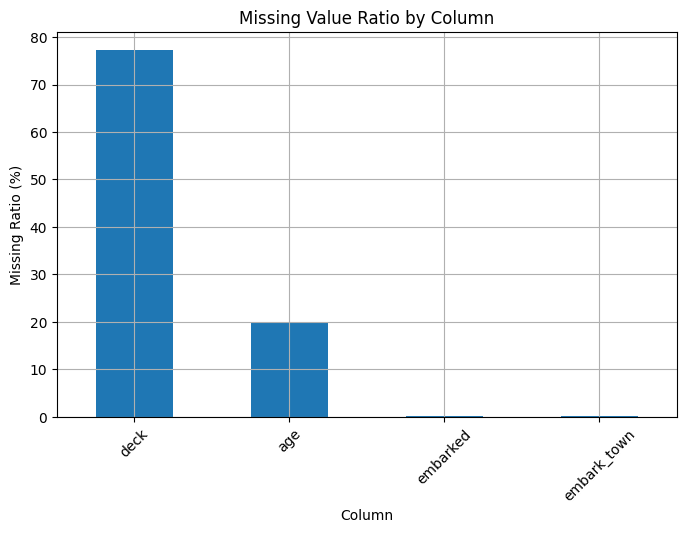

In [4]:
# 2. 결측치 개수와 비율 확인
missing_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_ratio": df.isnull().mean() * 100
})

missing_df = missing_df.sort_values(by="missing_ratio", ascending=False)

display(missing_df)

#결측치 비율 시각
missing_df[missing_df["missing_count"] > 0]["missing_ratio"].plot(kind="bar")

plt.title("Missing Value Ratio by Column")
plt.ylabel("Missing Ratio (%)")
plt.xlabel("Column")
plt.xticks(rotation=45)
plt.show()

survived
0    549
1    342
Name: count, dtype: int64
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


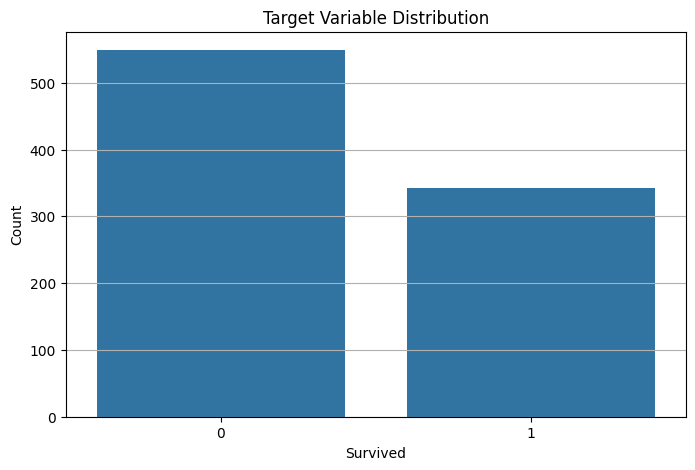

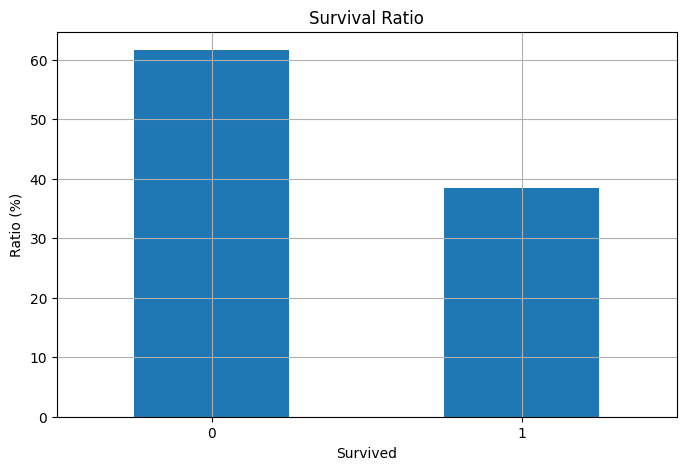

In [5]:
# 3. 타겟 변수 분포 확인
print(df["survived"].value_counts())
print(df["survived"].value_counts(normalize=True) * 100)

sns.countplot(data=df, x="survived")

plt.title("Target Variable Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

#생존 여부 비율 Barplot
survival_ratio = df["survived"].value_counts(normalize=True) * 100

survival_ratio.plot(kind="bar")

plt.title("Survival Ratio")
plt.xlabel("Survived")
plt.ylabel("Ratio (%)")
plt.xticks(rotation=0)
plt.show()

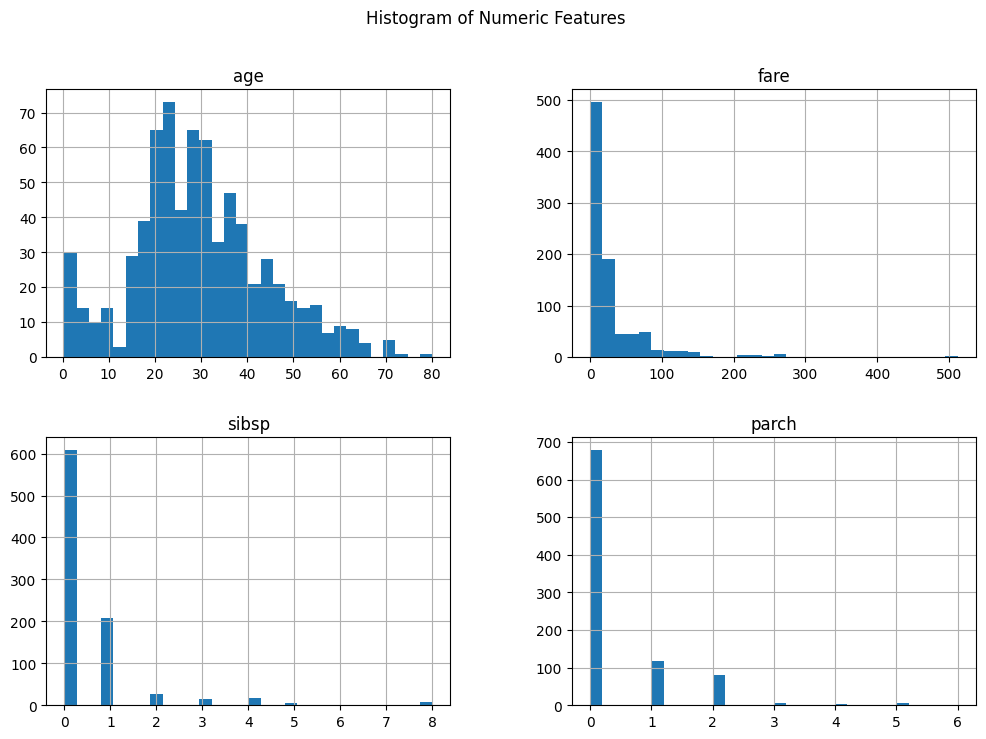

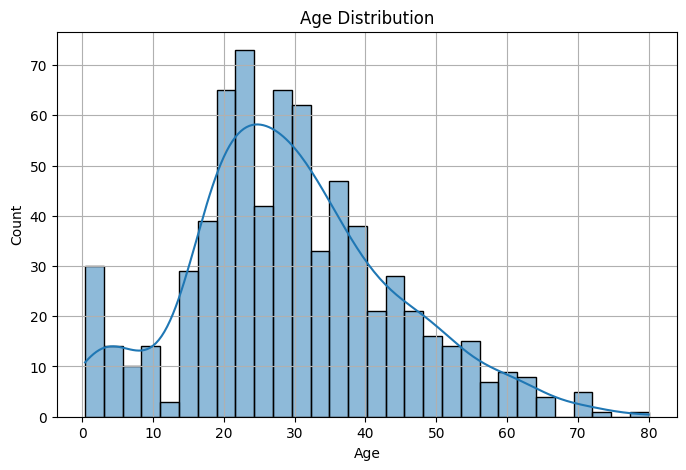

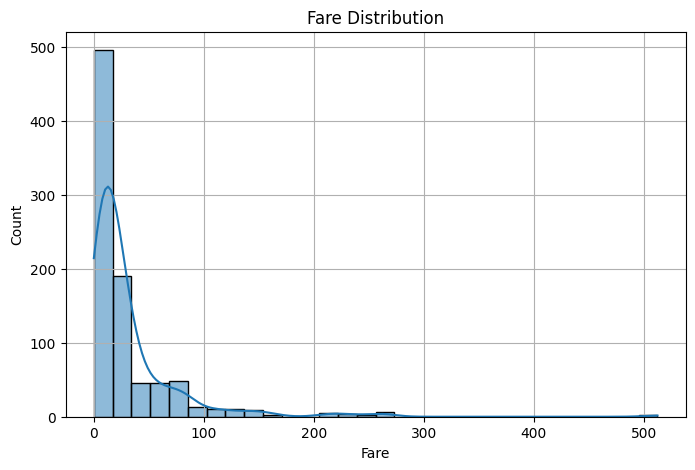

In [6]:
# 4. 변수 분포 시각화 히스토그램
numeric_cols = ["age", "fare", "sibsp", "parch"]

df[numeric_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle("Histogram of Numeric Features")
plt.show()

# 개별 Histogram 예시
sns.histplot(data=df, x="age", bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

sns.histplot(data=df, x="fare", bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()



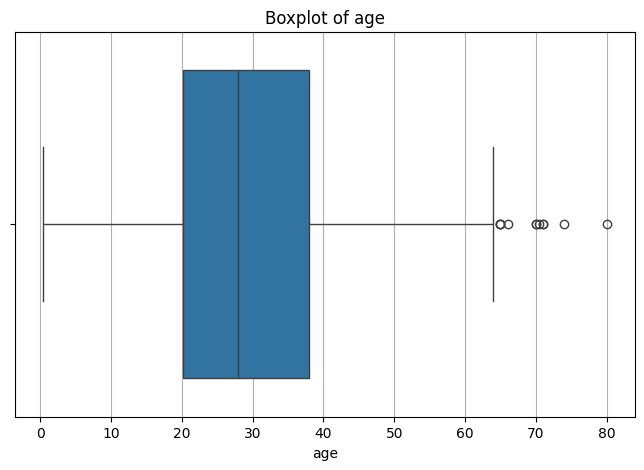

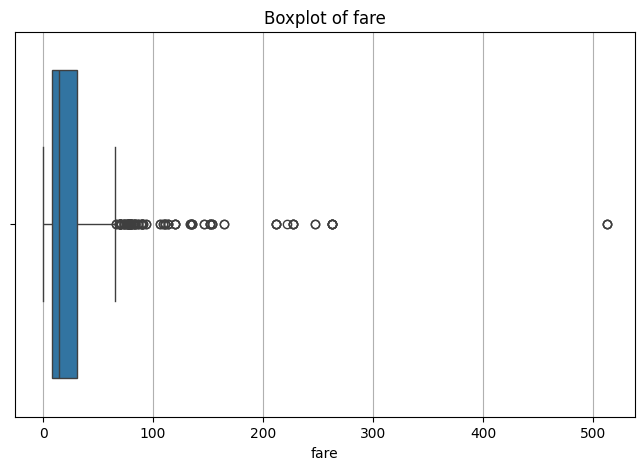

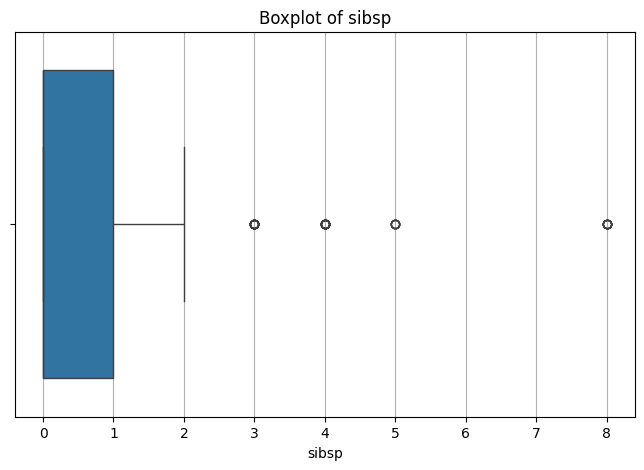

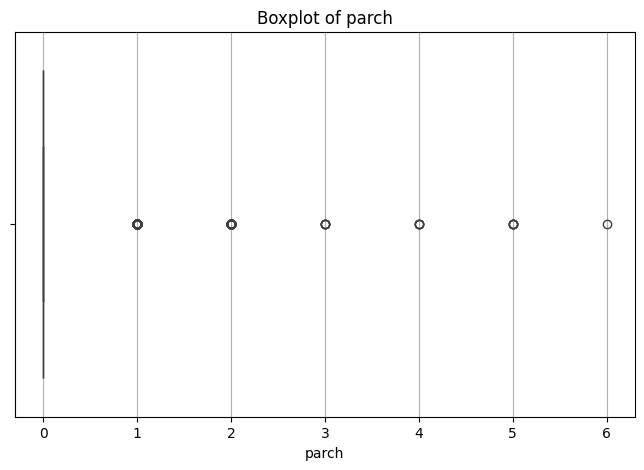

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_ratio
0,age,20.1250,38.0,17.8750,-6.6875,64.8125,11,1.540616
1,fare,7.9104,31.0,23.0896,-26.7240,65.6344,116,13.019080
2,sibsp,0.0000,1.0,1.0000,-1.5000,2.5000,46,5.162738
3,parch,0.0000,0.0,0.0000,0.0000,0.0000,213,23.905724


In [7]:
# 5. 이상치 탐지 Boxplot
for col in numeric_cols:
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

#IQR 방식으로 이상치 개수 확인
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_ratio = outlier_count / df[col].notnull().sum() * 100

    outlier_summary.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_ratio": outlier_ratio
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

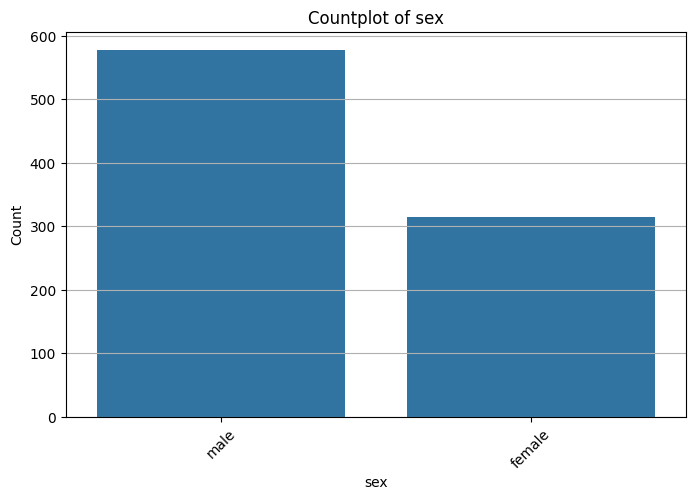

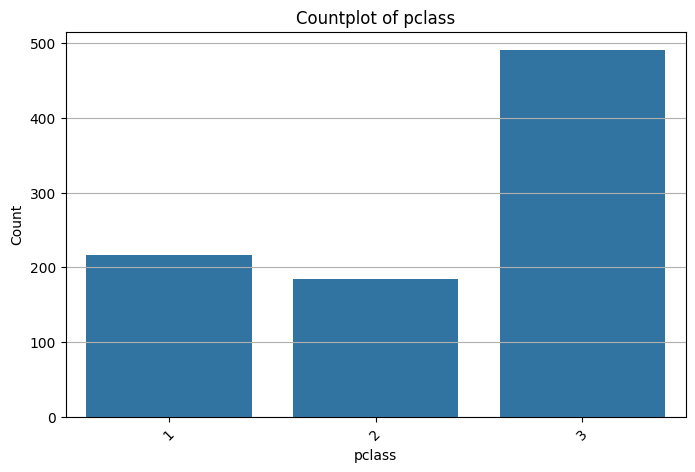

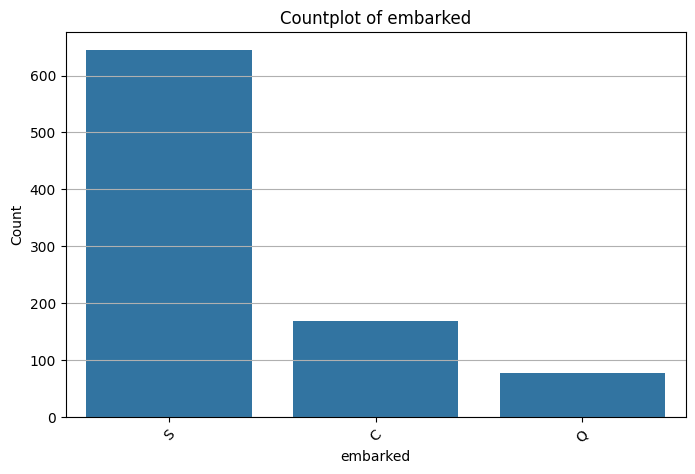

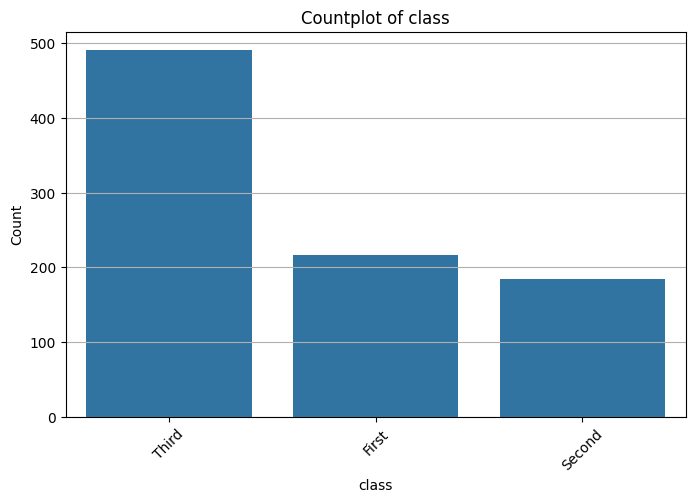

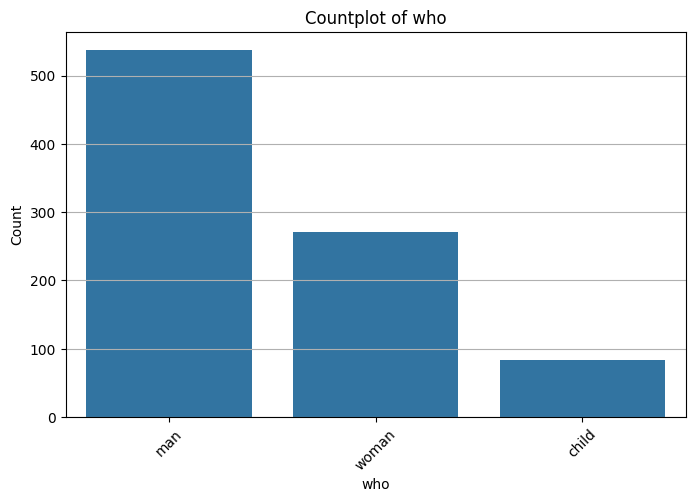

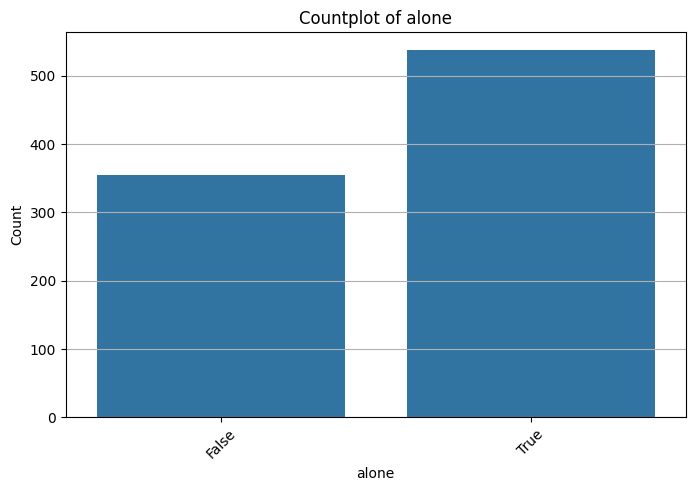

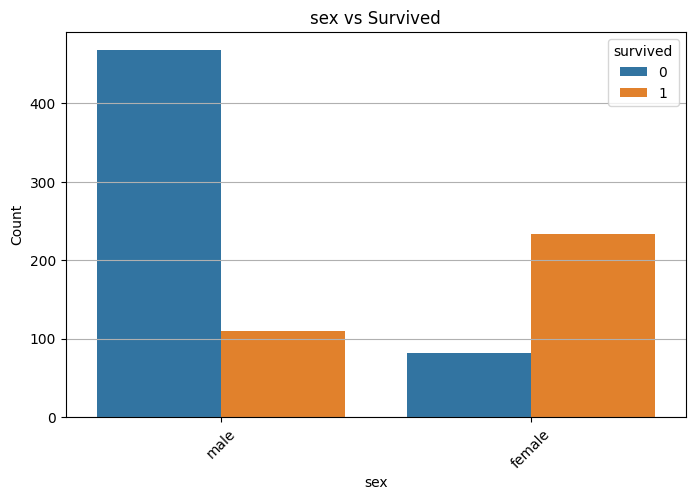

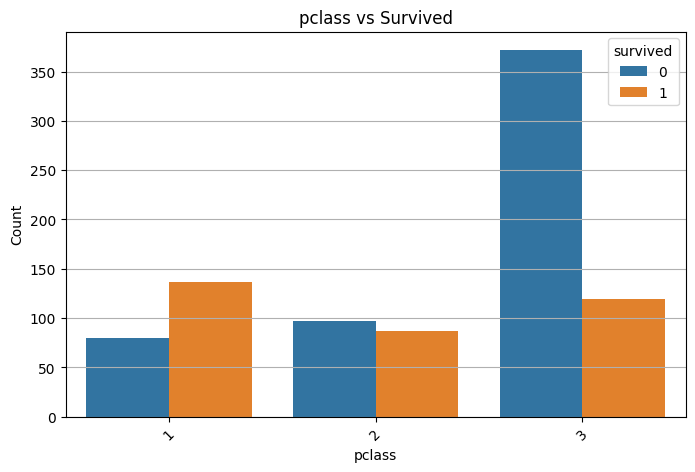

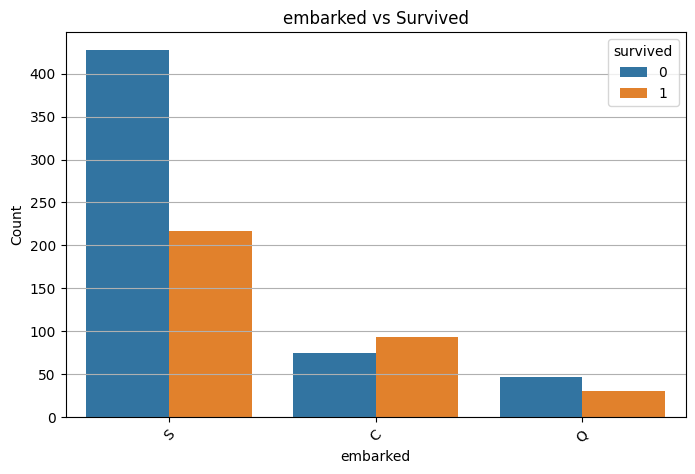

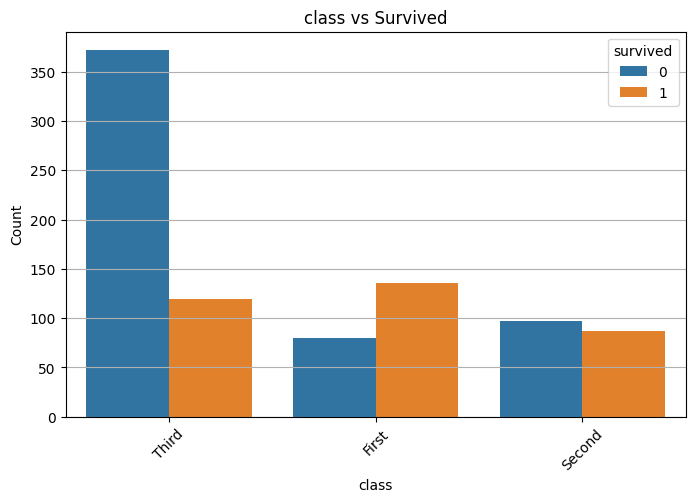

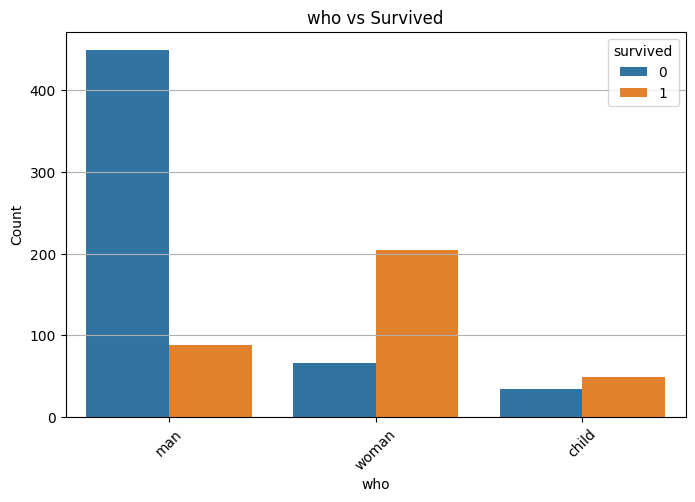

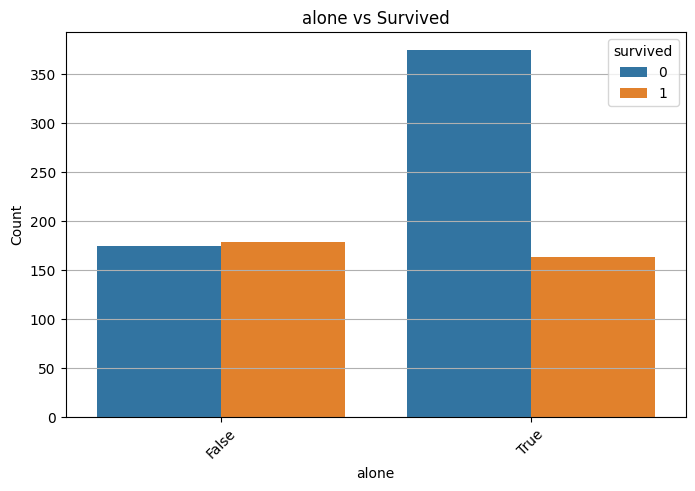

In [8]:
# 6. 범주형 변수 분포 Countplot
categorical_cols = ["sex", "pclass", "embarked", "class", "who", "alone"]

for col in categorical_cols:
    sns.countplot(data=df, x=col)
    plt.title(f"Countplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# 타겟 변수와 범주형 변수 관계 확인
for col in ["sex", "pclass", "embarked", "class", "who", "alone"]:
    sns.countplot(data=df, x=col, hue="survived")
    plt.title(f"{col} vs Survived")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

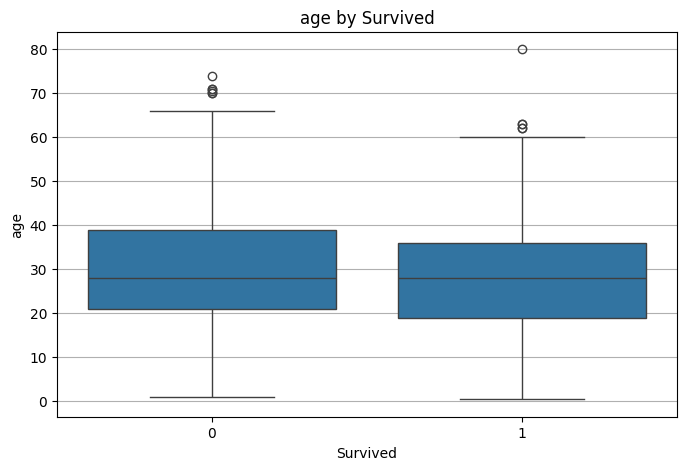

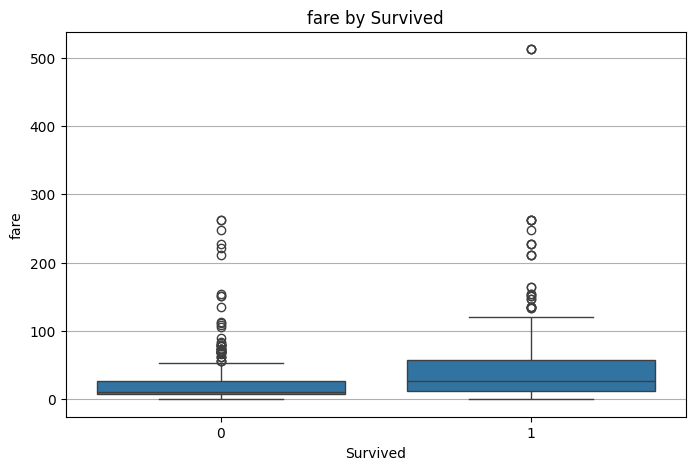

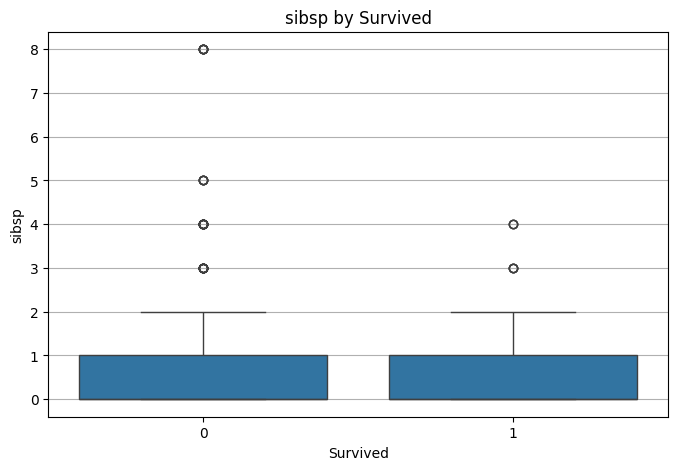

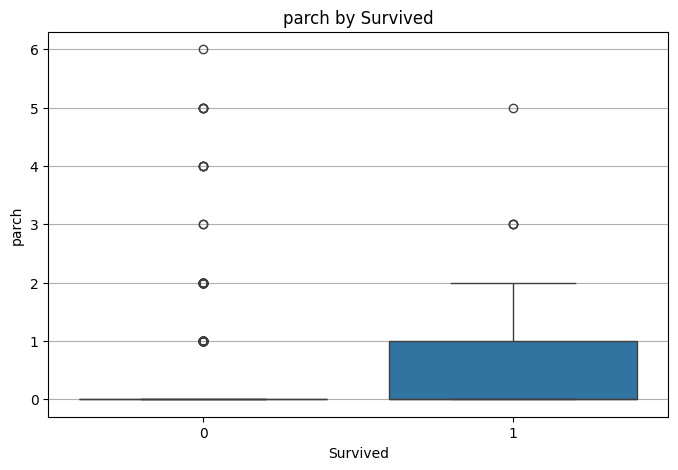

In [9]:
# 7. 수치형 변수와 타켓 변수 관계
for col in numeric_cols:
    sns.boxplot(data=df, x="survived", y=col)
    plt.title(f"{col} by Survived")
    plt.xlabel("Survived")
    plt.ylabel(col)
    plt.show()

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


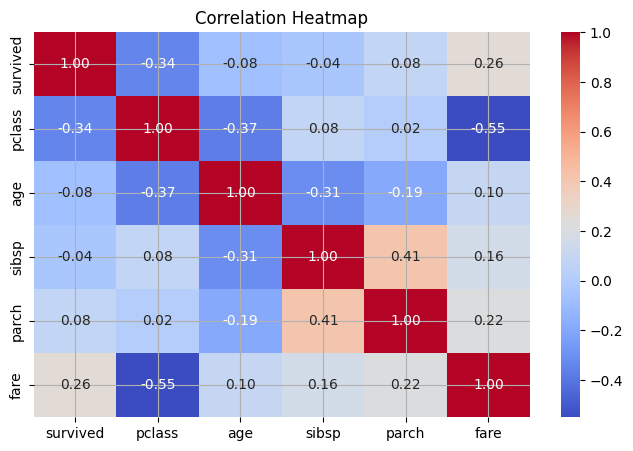

In [10]:
# 8. 상관관계 분석 Heatmap
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr_matrix = df[corr_cols].corr()

display(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [11]:
# 9. 추가 분석 : 생존율 비교표

# 성별 생존율
display(df.groupby("sex")["survived"].mean().reset_index().rename(columns={"survived": "survival_rate"}))

# 객실 등급별 생존율
display(df.groupby("pclass")["survived"].mean().reset_index().rename(columns={"survived": "survival_rate"}))

# 탑승 항구별 생존율
display(df.groupby("embarked")["survived"].mean().reset_index().rename(columns={"survived": "survival_rate"}))

# 혼자 탑승 여부별 생존율
display(df.groupby("alone")["survived"].mean().reset_index().rename(columns={"survived": "survival_rate"}))

,sex,survival_rate
0,female,0.742038
1,male,0.188908


,pclass,survival_rate
0,1,0.629630
1,2,0.472826
2,3,0.242363


,embarked,survival_rate
0,C,0.553571
1,Q,0.389610
2,S,0.336957


,alone,survival_rate
0,False,0.505650
1,True,0.303538


#STEP 03. 특성 공학 파이프라인 구현 및 비교 실험

In [12]:
# 1. 타켓 변수 및 불필요 컬럼 제거

target = "survived"

# 데이터 누수 또는 중복 가능성이 큰 컬럼 제거
drop_cols = ["survived", "alive", "deck", "class", "embark_town"]

X_base = df.drop(columns=drop_cols)
y = df[target]

display(X_base.head())
print("X shape:", X_base.shape)
print("y shape:", y.shape)

,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone
0,3,male,22.0,1,0,7.2500,S,man,True,False
1,1,female,38.0,1,0,71.2833,C,woman,False,False
2,3,female,26.0,0,0,7.9250,S,woman,False,True
3,1,female,35.0,1,0,53.1000,S,woman,False,False
4,3,male,35.0,0,0,8.0500,S,man,True,True


X shape: (891, 10)
y shape: (891,)


In [13]:
# 2. 파생 변수 생성

def create_features(X):
    X = X.copy()

    # 1. 가족 수 = 형제/배우자 + 부모/자녀 + 본인
    X["family_size"] = X["sibsp"] + X["parch"] + 1

    # 2. 1인당 요금
    X["fare_per_person"] = X["fare"] / X["family_size"]

    # 3. 나이 그룹
    X["age_group"] = pd.cut(
        X["age"],
        bins=[0, 12, 19, 35, 60, 100],
        labels=["child", "teen", "young_adult", "adult", "senior"]
    )

    # 4. 어린이 여부
    X["is_child"] = np.where(
        X["age"].isnull(),
        np.nan,
        np.where(X["age"] < 12, 1, 0)
    )

    return X

X = create_features(X_base)

display(X.head())
print("Feature Engineering 이후 shape:", X.shape)

,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone,family_size,fare_per_person,age_group,is_child
0,3,male,22.0,1,0,7.2500,S,man,True,False,2,3.62500,young_adult,0.0
1,1,female,38.0,1,0,71.2833,C,woman,False,False,2,35.64165,adult,0.0
2,3,female,26.0,0,0,7.9250,S,woman,False,True,1,7.92500,young_adult,0.0
3,1,female,35.0,1,0,53.1000,S,woman,False,False,2,26.55000,young_adult,0.0
4,3,male,35.0,0,0,8.0500,S,man,True,True,1,8.05000,young_adult,0.0


Feature Engineering 이후 shape: (891, 14)


/tmp/ipykernel_8401/1922012984.py:31: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8401/1922012984.py:31: UserWarning: Glyph 51313 (\N{HANGUL SYLLABLE JOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8401/1922012984.py:31: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8401/1922012984.py:31: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8401/1922012984.py:31: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8401/1922012984.py:31: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8401/1922012984.py:31: UserWarning: Glyph 54632 (\N{HANGUL SYLLABLE HAM}) missing from font(s) DejaVu Sans.
  plt.tight_layou

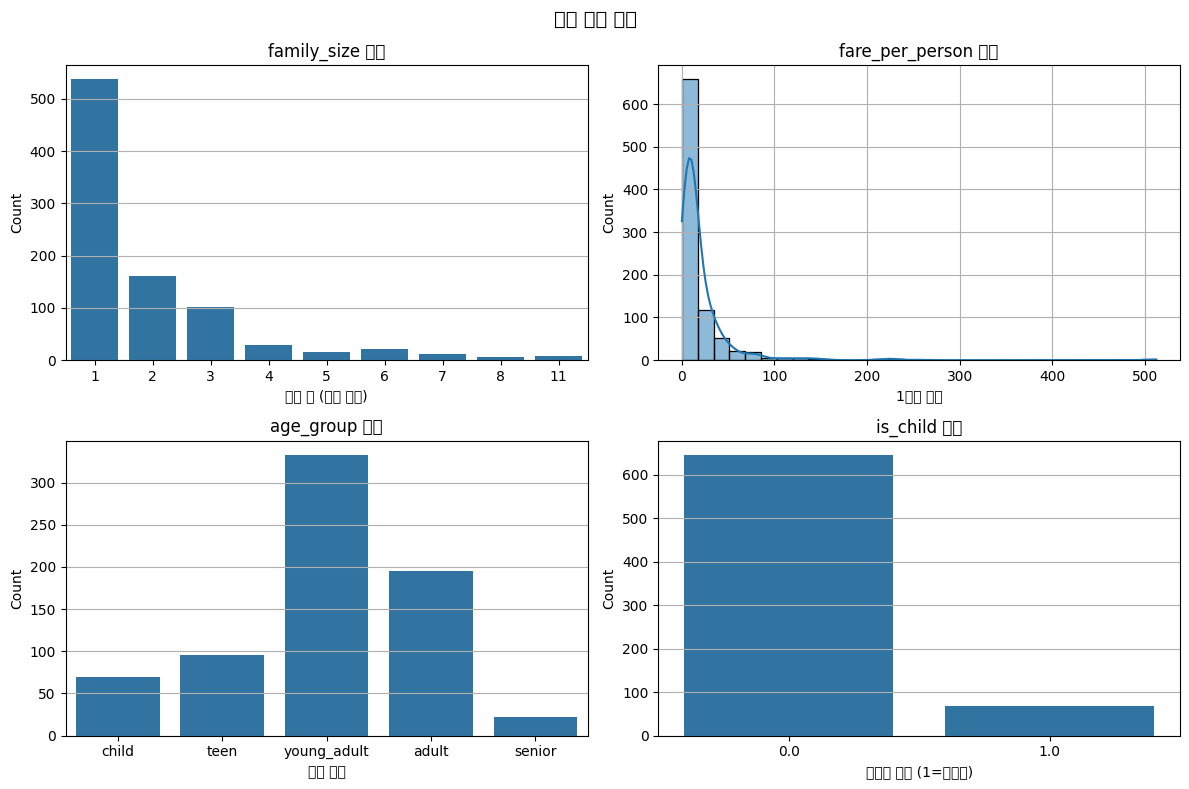

/tmp/ipykernel_8401/1922012984.py:61: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8401/1922012984.py:61: UserWarning: Glyph 51313 (\N{HANGUL SYLLABLE JOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8401/1922012984.py:61: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8401/1922012984.py:61: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8401/1922012984.py:61: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8401/1922012984.py:61: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8401/1922012984.py:61: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight

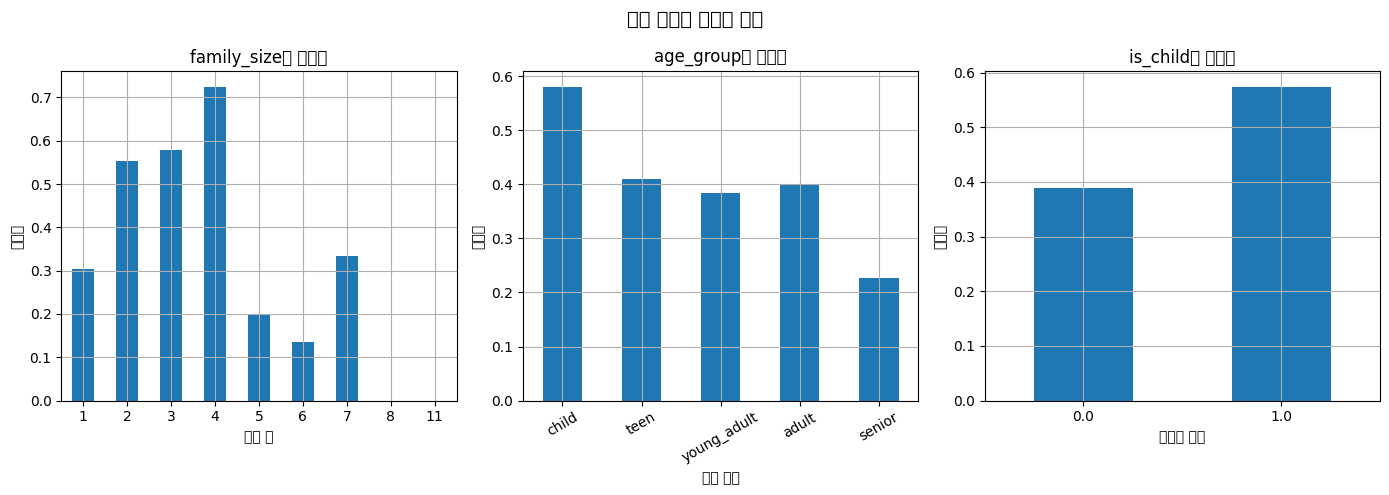

In [14]:
# 파생 변수 분포 시각화

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. family_size 분포
sns.countplot(data=X, x="family_size", ax=axes[0, 0])
axes[0, 0].set_title("family_size 분포")
axes[0, 0].set_xlabel("가족 수 (본인 포함)")
axes[0, 0].set_ylabel("Count")

# 2. fare_per_person 분포
sns.histplot(data=X, x="fare_per_person", bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("fare_per_person 분포")
axes[0, 1].set_xlabel("1인당 요금")
axes[0, 1].set_ylabel("Count")

# 3. age_group 분포
age_order = ["child", "teen", "young_adult", "adult", "senior"]
sns.countplot(data=X, x="age_group", order=age_order, ax=axes[1, 0])
axes[1, 0].set_title("age_group 분포")
axes[1, 0].set_xlabel("나이 그룹")
axes[1, 0].set_ylabel("Count")

# 4. is_child 분포
sns.countplot(data=X, x="is_child", ax=axes[1, 1])
axes[1, 1].set_title("is_child 분포")
axes[1, 1].set_xlabel("어린이 여부 (1=어린이)")
axes[1, 1].set_ylabel("Count")

plt.suptitle("파생 변수 분포", fontsize=14)
plt.tight_layout()
plt.show()

# 파생 변수와 생존율 관계
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# family_size별 생존율
temp = X.copy()
temp["survived"] = y.values
temp.groupby("family_size")["survived"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("family_size별 생존율")
axes[0].set_xlabel("가족 수")
axes[0].set_ylabel("생존율")
axes[0].tick_params(axis="x", rotation=0)

# age_group별 생존율
temp.groupby("age_group", observed=True)["survived"].mean().reindex(age_order).plot(kind="bar", ax=axes[1])
axes[1].set_title("age_group별 생존율")
axes[1].set_xlabel("나이 그룹")
axes[1].set_ylabel("생존율")
axes[1].tick_params(axis="x", rotation=30)

# is_child별 생존율
temp.groupby("is_child")["survived"].mean().plot(kind="bar", ax=axes[2])
axes[2].set_title("is_child별 생존율")
axes[2].set_xlabel("어린이 여부")
axes[2].set_ylabel("생존율")
axes[2].tick_params(axis="x", rotation=0)

plt.suptitle("파생 변수와 생존율 관계", fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# 3. 수치형/범주형 변수 구분

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "family_size",
    "fare_per_person",
    "is_child"
]

categorical_features = [
    "sex",
    "embarked",
    "who",
    "adult_male",
    "alone",
    "age_group"
]

# 범주형 변수는 object 타입으로 변환
for col in categorical_features:
    X[col] = X[col].astype("object")

print("수치형 변수:", numeric_features)
print("범주형 변수:", categorical_features)

수치형 변수: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'fare_per_person', 'is_child']
범주형 변수: ['sex', 'embarked', 'who', 'adult_male', 'alone', 'age_group']


#비교 실험용 Pipeline 구성

비교할 방법은 다음과 같습니다.

##결측치 처리 비교
| 방법                     | 설명                 |
| ---------------------- | ------------------ |
| Mean + Most Frequent   | 수치형은 평균, 범주형은 최빈값  |
| Median + Most Frequent | 수치형은 중앙값, 범주형은 최빈값 |
| Drop NA                | 결측치가 있는 행 제거       |

##인코딩 비교
| 방법                | 설명                                     |
| ----------------- | -------------------------------------- |
| One-Hot Encoding  | 범주를 여러 개의 0/1 컬럼으로 변환                  |
| Label Encoding 계열 | 범주를 정수값으로 변환, 여기서는 `OrdinalEncoder` 사용 |

##스케일링 비교
| 방법             | 설명                          |
| -------------- | --------------------------- |
| StandardScaler | 평균 0, 표준편차 1로 변환            |
| MinMaxScaler   | 0~1 범위로 변환                  |
| RobustScaler   | 중앙값과 IQR 기반 변환, 이상치에 비교적 강함 |


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [17]:
# 5. 실험 함수 만들기

def build_pipeline(missing_strategy, encoding_strategy, scaling_strategy):

    # 스케일러 선택
    if scaling_strategy == "standard":
        scaler = StandardScaler()
    elif scaling_strategy == "minmax":
        scaler = MinMaxScaler()
    elif scaling_strategy == "robust":
        scaler = RobustScaler()
    else:
        raise ValueError("지원하지 않는 scaling_strategy입니다.")

    # 인코더 선택
    if encoding_strategy == "onehot":
        encoder = OneHotEncoder(handle_unknown="ignore")
    elif encoding_strategy == "label":
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    else:
        raise ValueError("지원하지 않는 encoding_strategy입니다.")

    # 결측치 처리 방식
    if missing_strategy == "mean":
        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", scaler)
        ])

        categorical_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", encoder)
        ])

    elif missing_strategy == "median":
        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", scaler)
        ])

        categorical_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", encoder)
        ])

    elif missing_strategy == "dropna":
        # Drop NA는 실험 전에 행을 제거하므로 pipeline 내부 imputer는 사용하지 않음
        numeric_pipeline = Pipeline([
            ("scaler", scaler)
        ])

        categorical_pipeline = Pipeline([
            ("encoder", encoder)
        ])

    else:
        raise ValueError("지원하지 않는 missing_strategy입니다.")

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

    model = LogisticRegression(max_iter=1000)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return pipeline

In [18]:
# 6. 결측치 처리/인코딩/스케일링 조합 비교 실험

missing_strategies = ["mean", "median", "dropna"]
encoding_strategies = ["onehot", "label"]
scaling_strategies = ["standard", "minmax", "robust"]

results = []

for missing_strategy in missing_strategies:
    for encoding_strategy in encoding_strategies:
        for scaling_strategy in scaling_strategies:

            X_exp = X.copy()
            y_exp = y.copy()

            # Drop NA 방식일 경우 결측치가 있는 행 제거
            if missing_strategy == "dropna":
                temp = X_exp.copy()
                temp[target] = y_exp

                temp = temp.dropna(
                    subset=numeric_features + categorical_features + [target]
                )

                X_exp = temp[numeric_features + categorical_features]
                y_exp = temp[target]
            else:
                X_exp = X_exp[numeric_features + categorical_features]

            # Train/Test Split
            X_train, X_test, y_train, y_test = train_test_split(
                X_exp,
                y_exp,
                test_size=0.2,
                random_state=42,
                stratify=y_exp
            )

            # Pipeline 생성
            pipeline = build_pipeline(
                missing_strategy=missing_strategy,
                encoding_strategy=encoding_strategy,
                scaling_strategy=scaling_strategy
            )

            # 학습
            pipeline.fit(X_train, y_train)

            # 예측
            y_pred = pipeline.predict(X_test)

            # 평가
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)

            # 변환 후 feature 수 확인
            transformed_train = pipeline.named_steps["preprocessor"].transform(X_train)
            n_transformed_features = transformed_train.shape[1]

            results.append({
                "missing_strategy": missing_strategy,
                "encoding_strategy": encoding_strategy,
                "scaling_strategy": scaling_strategy,
                "n_samples": len(X_exp),
                "n_features_after_transform": n_transformed_features,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1_score": f1
            })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="f1_score", ascending=False)

display(results_df)

,missing_strategy,encoding_strategy,scaling_strategy,n_samples,n_features_after_transform,accuracy,precision,recall,f1_score
6,median,onehot,standard,891,25,0.843575,0.825397,0.753623,0.787879
2,mean,onehot,robust,891,25,0.843575,0.825397,0.753623,0.787879
8,median,onehot,robust,891,25,0.843575,0.825397,0.753623,0.787879
16,dropna,label,minmax,712,14,0.825175,0.779661,0.793103,0.786325
17,dropna,label,robust,712,14,0.825175,0.779661,0.793103,0.786325
1,mean,onehot,minmax,891,25,0.837989,0.812500,0.753623,0.781955
7,median,onehot,minmax,891,25,0.837989,0.812500,0.753623,0.781955
0,mean,onehot,standard,891,25,0.837989,0.822581,0.739130,0.778626
14,dropna,onehot,robust,712,25,0.818182,0.775862,0.775862,0.775862
3,mean,label,standard,891,14,0.832402,0.809524,0.739130,0.772727


In [19]:
# 7. 결측치 처리 방법별 평균 성능 비교
missing_compare = results_df.groupby("missing_strategy")[
    ["accuracy", "precision", "recall", "f1_score"]
].mean().sort_values(by="f1_score", ascending=False)

display(missing_compare)

,accuracy,precision,recall,f1_score
missing_strategy,,,,
median,0.835196,0.814270,0.741546,0.776169
dropna,0.818182,0.777460,0.772989,0.775146
mean,0.833333,0.811641,0.739130,0.773668


In [20]:
# 8. 인코딩 방법별 평균 성능 비교
encoding_compare = results_df.groupby("encoding_strategy")[
    ["accuracy", "precision", "recall", "f1_score"]
].mean().sort_values(by="f1_score", ascending=False)

display(encoding_compare)

,accuracy,precision,recall,f1_score
encoding_strategy,,,,
onehot,0.832472,0.806364,0.755594,0.779909
label,0.825335,0.795883,0.746849,0.770079


In [21]:
# 9. 스케일링 방법별 평균 성능 비교

scaling_compare = results_df.groupby("scaling_strategy")[
    ["accuracy", "precision", "recall", "f1_score"]
].mean().sort_values(by="f1_score", ascending=False)

display(scaling_compare)

,accuracy,precision,recall,f1_score
scaling_strategy,,,,
robust,0.832552,0.804227,0.759079,0.780566
standard,0.828124,0.801814,0.748043,0.773732
minmax,0.826034,0.797329,0.746543,0.770684


In [22]:
# 10. 가장 좋은 조합 확인

best_result = results_df.iloc[0]
display(best_result)

,6
missing_strategy,median
encoding_strategy,onehot
scaling_strategy,standard
n_samples,891
n_features_after_transform,25
accuracy,0.843575
precision,0.825397
recall,0.753623
f1_score,0.787879


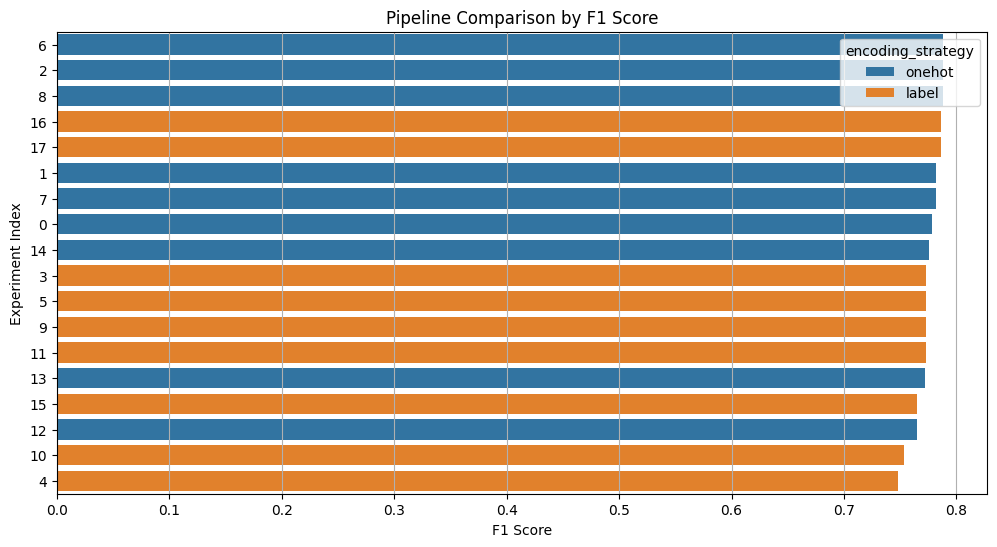

In [23]:
# 11. 결과 시각화

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="f1_score",
    y=results_df.index.astype(str),
    hue="encoding_strategy"
)

plt.title("Pipeline Comparison by F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Experiment Index")
plt.show()

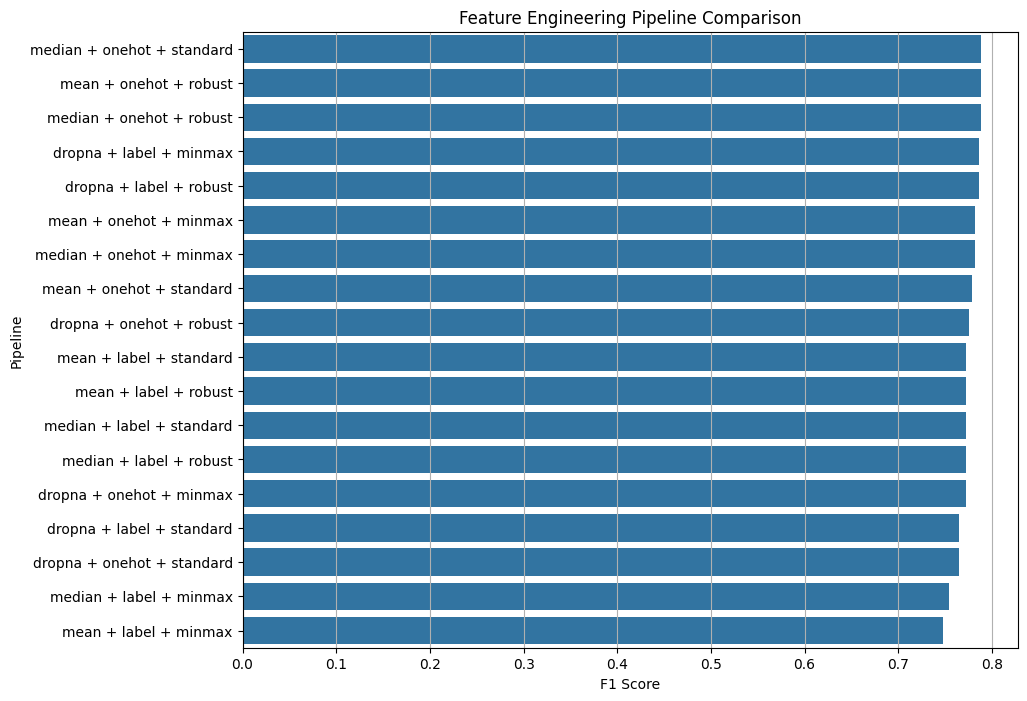

In [24]:
results_df["experiment"] = (
    results_df["missing_strategy"] + " + " +
    results_df["encoding_strategy"] + " + " +
    results_df["scaling_strategy"]
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=results_df,
    x="f1_score",
    y="experiment"
)

plt.title("Feature Engineering Pipeline Comparison")
plt.xlabel("F1 Score")
plt.ylabel("Pipeline")
plt.show()

#STEP 04. 변수 선택(Feature Selection)

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [26]:
# ------------------------------------------------------------
# 1. 데이터 로드
# 이전 단계에서 df가 있으면 그대로 사용하고,
# 없으면 Titanic 데이터를 다시 불러옴
# ------------------------------------------------------------

try:
    df
except NameError:
    url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
    df = pd.read_csv(url)

print("원본 데이터 shape:", df.shape)
display(df.head())

원본 데이터 shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [27]:
# ------------------------------------------------------------
# 2. 파생 변수 생성
# ------------------------------------------------------------

data = df.copy()

# 가족 수 = 형제/배우자 수 + 부모/자녀 수 + 본인
data["family_size"] = data["sibsp"] + data["parch"] + 1

# 1인당 요금
data["fare_per_person"] = data["fare"] / data["family_size"]

# 나이 그룹 생성
data["age_group"] = pd.cut(
    data["age"],
    bins=[0, 12, 19, 35, 60, 100],
    labels=["child", "teen", "young_adult", "adult", "senior"]
)

# 어린이 여부
data["is_child"] = np.where(
    data["age"].isnull(),
    np.nan,
    np.where(data["age"] < 12, 1, 0)
)

display(data.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,fare_per_person,age_group,is_child
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2,3.62500,young_adult,0.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2,35.64165,adult,0.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1,7.92500,young_adult,0.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2,26.55000,young_adult,0.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,8.05000,young_adult,0.0


In [28]:
# ------------------------------------------------------------
# 3. 입력 변수 X와 타겟 변수 y 분리
# ------------------------------------------------------------

target = "survived"

# survived: 타겟 변수
# alive: survived와 같은 정보를 담고 있어 데이터 누수 위험
# deck: 결측치가 너무 많음
# class, embark_town: pclass, embarked와 의미가 중복됨
drop_cols = ["survived", "alive", "deck", "class", "embark_town"]

X = data.drop(columns=drop_cols)
y = data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (891, 14)
y shape: (891,)


,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone,family_size,fare_per_person,age_group,is_child
0,3,male,22.0,1,0,7.2500,S,man,True,False,2,3.62500,young_adult,0.0
1,1,female,38.0,1,0,71.2833,C,woman,False,False,2,35.64165,adult,0.0
2,3,female,26.0,0,0,7.9250,S,woman,False,True,1,7.92500,young_adult,0.0
3,1,female,35.0,1,0,53.1000,S,woman,False,False,2,26.55000,young_adult,0.0
4,3,male,35.0,0,0,8.0500,S,man,True,True,1,8.05000,young_adult,0.0


In [29]:
# ------------------------------------------------------------
# 4. 수치형 변수와 범주형 변수 구분
# ------------------------------------------------------------

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "family_size",
    "fare_per_person",
    "is_child"
]

categorical_features = [
    "sex",
    "embarked",
    "who",
    "adult_male",
    "alone",
    "age_group"
]

# 범주형 변수는 object 타입으로 변환
for col in categorical_features:
    X[col] = X[col].astype("object")

print("수치형 변수:", numeric_features)
print("범주형 변수:", categorical_features)

수치형 변수: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'fare_per_person', 'is_child']
범주형 변수: ['sex', 'embarked', 'who', 'adult_male', 'alone', 'age_group']


In [30]:
# ------------------------------------------------------------
# 5. Train/Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X[numeric_features + categorical_features],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 14)
X_test shape: (179, 14)
y_train shape: (712,)
y_test shape: (179,)


In [31]:
# ------------------------------------------------------------
# 6. 전처리 파이프라인 구성
# 수치형: 중앙값 결측치 대체 + RobustScaler
# 범주형: 최빈값 결측치 대체 + One-Hot Encoding
# ------------------------------------------------------------

# sklearn 버전 차이 대응
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", onehot)
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [32]:
# ------------------------------------------------------------
# 7. 전처리 적용
# ------------------------------------------------------------

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print("전처리 후 X_train shape:", X_train_preprocessed.shape)
print("전처리 후 X_test shape:", X_test_preprocessed.shape)

전처리 후 X_train shape: (712, 25)
전처리 후 X_test shape: (179, 25)


In [33]:
# ------------------------------------------------------------
# 8. 전처리 후 생성된 변수 이름 확인
# ------------------------------------------------------------

cat_encoder = preprocessor.named_transformers_["cat"].named_steps["encoder"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(cat_feature_names)

print("전처리 후 전체 변수 개수:", len(all_feature_names))
print(all_feature_names)

전처리 후 전체 변수 개수: 25
['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'fare_per_person', 'is_child', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'who_child', 'who_man', 'who_woman', 'adult_male_False', 'adult_male_True', 'alone_False', 'alone_True', 'age_group_adult', 'age_group_child', 'age_group_senior', 'age_group_teen', 'age_group_young_adult']


In [34]:
# ------------------------------------------------------------
# 9. 모델 성능 평가 함수
# ------------------------------------------------------------

def evaluate_model(model, X_train_data, X_test_data, y_train, y_test, model_name):
    model.fit(X_train_data, y_train)
    y_pred = model.predict(X_test_data)

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred)
    }

    return result

In [35]:
# ------------------------------------------------------------
# 10. 변수 선택 전 성능 측정
# 전체 변수를 모두 사용
# ------------------------------------------------------------

baseline_model = LogisticRegression(max_iter=1000)

baseline_result = evaluate_model(
    model=baseline_model,
    X_train_data=X_train_preprocessed,
    X_test_data=X_test_preprocessed,
    y_train=y_train,
    y_test=y_test,
    model_name="Before Feature Selection - All Features"
)

baseline_df = pd.DataFrame([baseline_result])
display(baseline_df)

,model,accuracy,precision,recall,f1_score
0,Before Feature Selection - All Features,0.843575,0.825397,0.753623,0.787879


In [36]:
# ------------------------------------------------------------
# 11. Random Forest Feature Importance 계산
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_preprocessed, y_train)

feature_importance_df = pd.DataFrame({
    "feature_index": range(len(all_feature_names)),
    "feature": all_feature_names,
    "importance": rf_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance_df.head(20))

,feature_index,feature,importance
0,6,fare_per_person,0.159727
1,1,age,0.154628
2,4,fare,0.144861
3,14,who_man,0.071825
4,16,adult_male_False,0.060555
5,17,adult_male_True,0.056671
6,0,pclass,0.052420
7,8,sex_female,0.048097
8,9,sex_male,0.046830
9,5,family_size,0.037582


In [37]:
# ------------------------------------------------------------
# 12. 중요도 상위 N개 변수 선정
# ------------------------------------------------------------

top_n = 10

top_features_df = feature_importance_df.head(top_n)

selected_feature_indices = top_features_df["feature_index"].values
selected_feature_names = top_features_df["feature"].values

print(f"선택된 중요도 상위 {top_n}개 변수")

for i, feature in enumerate(selected_feature_names, start=1):
    print(f"{i}. {feature}")

display(top_features_df)

선택된 중요도 상위 10개 변수
1. fare_per_person
2. age
3. fare
4. who_man
5. adult_male_False
6. adult_male_True
7. pclass
8. sex_female
9. sex_male
10. family_size


,feature_index,feature,importance
0,6,fare_per_person,0.159727
1,1,age,0.154628
2,4,fare,0.144861
3,14,who_man,0.071825
4,16,adult_male_False,0.060555
5,17,adult_male_True,0.056671
6,0,pclass,0.052420
7,8,sex_female,0.048097
8,9,sex_male,0.046830
9,5,family_size,0.037582


In [38]:
# ------------------------------------------------------------
# 13. 선택된 변수만 사용하도록 데이터 축소
# ------------------------------------------------------------

X_train_selected = X_train_preprocessed[:, selected_feature_indices]
X_test_selected = X_test_preprocessed[:, selected_feature_indices]

print("변수 선택 전 X_train shape:", X_train_preprocessed.shape)
print("변수 선택 후 X_train shape:", X_train_selected.shape)

print("변수 선택 전 X_test shape:", X_test_preprocessed.shape)
print("변수 선택 후 X_test shape:", X_test_selected.shape)

변수 선택 전 X_train shape: (712, 25)
변수 선택 후 X_train shape: (712, 10)
변수 선택 전 X_test shape: (179, 25)
변수 선택 후 X_test shape: (179, 10)


In [39]:
# ------------------------------------------------------------
# 14. 변수 선택 후 성능 측정
# 상위 N개 변수만 사용
# ------------------------------------------------------------

selected_model = LogisticRegression(max_iter=1000)

selected_result = evaluate_model(
    model=selected_model,
    X_train_data=X_train_selected,
    X_test_data=X_test_selected,
    y_train=y_train,
    y_test=y_test,
    model_name=f"After Feature Selection - Top {top_n} Features"
)

selected_df = pd.DataFrame([selected_result])
display(selected_df)

,model,accuracy,precision,recall,f1_score
0,After Feature Selection - Top 10 Features,0.826816,0.806452,0.724638,0.763359


In [40]:
# ------------------------------------------------------------
# 15. 변수 선택 전/후 성능 비교
# ------------------------------------------------------------

comparison_df = pd.DataFrame([baseline_result, selected_result])

display(comparison_df)

,model,accuracy,precision,recall,f1_score
0,Before Feature Selection - All Features,0.843575,0.825397,0.753623,0.787879
1,After Feature Selection - Top 10 Features,0.826816,0.806452,0.724638,0.763359


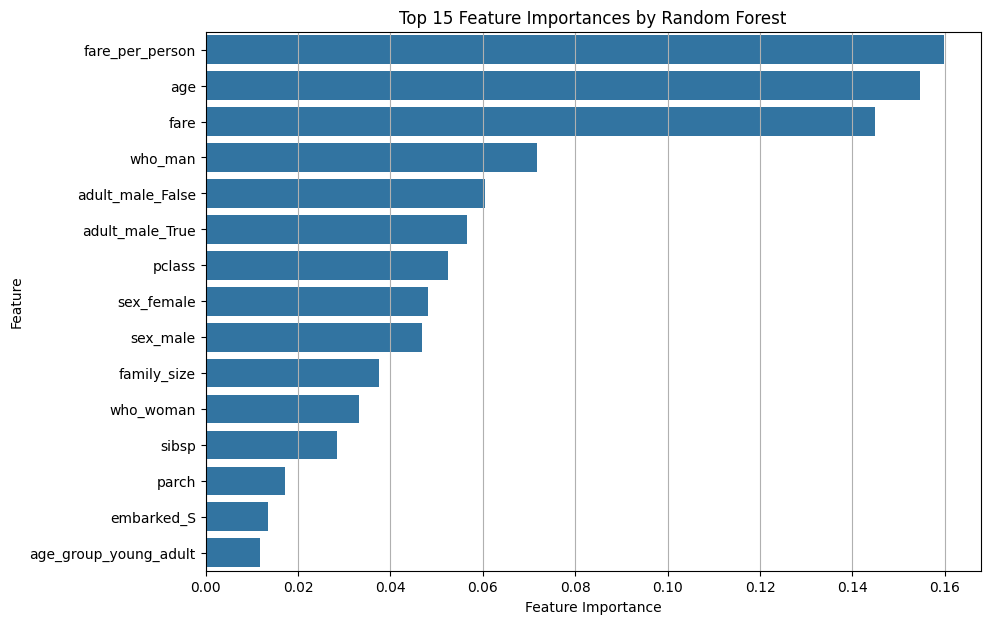

In [41]:
# ------------------------------------------------------------
# 16. Feature Importance 시각화
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_df.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 Feature Importances by Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

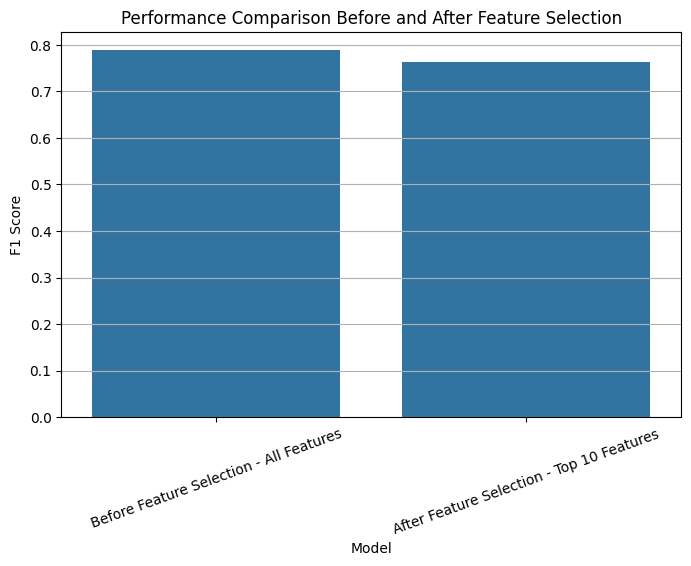

In [42]:
# ------------------------------------------------------------
# 17. 변수 선택 전/후 성능 시각화
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_df,
    x="model",
    y="f1_score"
)

plt.title("Performance Comparison Before and After Feature Selection")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)
plt.show()

In [43]:
# ------------------------------------------------------------
# 18. STEP 04 결과 요약
# ------------------------------------------------------------

print("="*60)
print("STEP 04 Feature Selection 요약")
print("="*60)

print(f"""
1. 변수 선택 방법
- Random Forest Feature Importance를 사용하였다.
- Random Forest 모델을 학습한 뒤 각 변수의 중요도를 계산하였다.
- 중요도 값이 높은 순서대로 상위 {top_n}개의 변수를 선택하였다.

2. 선택된 상위 {top_n}개 변수
{list(selected_feature_names)}

3. 변수 선택 전/후 성능 비교
- 변수 선택 전에는 전처리 후 생성된 전체 변수를 모두 사용하였다.
- 변수 선택 후에는 중요도 상위 {top_n}개 변수만 사용하였다.
- 두 경우 모두 동일한 Logistic Regression 모델을 사용하였다.

4. 해석
- 변수 선택 후 성능이 유지되거나 향상된다면 불필요한 변수를 제거해도 예측 성능이 유지된다는 의미이다.
- 변수 선택 후 성능이 하락한다면 제거된 변수 중 일부가 생존 여부 예측에 도움이 되었을 가능성이 있다.
- Feature Selection은 모델 복잡도를 줄이고 해석 가능성을 높이는 데 도움이 된다.
""")

STEP 04 Feature Selection 요약

1. 변수 선택 방법
- Random Forest Feature Importance를 사용하였다.
- Random Forest 모델을 학습한 뒤 각 변수의 중요도를 계산하였다.
- 중요도 값이 높은 순서대로 상위 10개의 변수를 선택하였다.

2. 선택된 상위 10개 변수
['fare_per_person', 'age', 'fare', 'who_man', 'adult_male_False', 'adult_male_True', 'pclass', 'sex_female', 'sex_male', 'family_size']

3. 변수 선택 전/후 성능 비교
- 변수 선택 전에는 전처리 후 생성된 전체 변수를 모두 사용하였다.
- 변수 선택 후에는 중요도 상위 10개 변수만 사용하였다.
- 두 경우 모두 동일한 Logistic Regression 모델을 사용하였다.

4. 해석
- 변수 선택 후 성능이 유지되거나 향상된다면 불필요한 변수를 제거해도 예측 성능이 유지된다는 의미이다.
- 변수 선택 후 성능이 하락한다면 제거된 변수 중 일부가 생존 여부 예측에 도움이 되었을 가능성이 있다.
- Feature Selection은 모델 복잡도를 줄이고 해석 가능성을 높이는 데 도움이 된다.



#STEP 05. 모델 학습 및 평가

In [44]:
# ============================================================
# STEP 05. 모델 학습 및 평가
# Classification: Titanic 생존 여부 예측
# 비교 모델: Logistic Regression, Random Forest, XGBoost
# 평가 지표: Accuracy, Precision, Recall, F1-score, ROC-AUC
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [45]:
# ------------------------------------------------------------
# 1. 최종 학습 데이터 설정
# STEP 04에서 만든 변수 선택 결과 사용
# ------------------------------------------------------------

X_train_final = X_train_selected
X_test_final = X_test_selected

print("최종 학습 데이터 shape:", X_train_final.shape)
print("최종 테스트 데이터 shape:", X_test_final.shape)
print("사용한 변수 개수:", X_train_final.shape[1])

최종 학습 데이터 shape: (712, 10)
최종 테스트 데이터 shape: (179, 10)
사용한 변수 개수: 10


In [46]:
# ------------------------------------------------------------
# 2. XGBoost 불러오기
# 설치되어 있으면 사용하고, 없으면 제외
# ------------------------------------------------------------

xgboost_available = True

try:
    from xgboost import XGBClassifier
    print("XGBoost 사용 가능")
except ImportError:
    xgboost_available = False
    print("XGBoost가 설치되어 있지 않아 제외합니다.")

# LightGBM 불러오기
lightgbm_available = True

try:
    from lightgbm import LGBMClassifier
    print("LightGBM 사용 가능")
except ImportError:
    lightgbm_available = False
    print("LightGBM이 설치되어 있지 않아 제외합니다.")

XGBoost 사용 가능
LightGBM 사용 가능


In [47]:
# ------------------------------------------------------------
# 3. 모델 정의
# 최소 2개 이상 비교 조건 충족
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )
}

# XGBoost가 사용 가능하면 모델 목록에 추가
if xgboost_available:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )

# LightGBM이 사용 가능하면 모델 목록에 추가
if lightgbm_available:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )

print("비교할 모델 목록:")
for model_name in models.keys():
    print("-", model_name)

비교할 모델 목록:
- Logistic Regression
- Random Forest
- XGBoost
- LightGBM


In [48]:
# ------------------------------------------------------------
# 4. 모델 평가 함수
# Accuracy, Precision, Recall, F1-score, ROC-AUC 계산
# ------------------------------------------------------------

def evaluate_classification_model(model, X_train, X_test, y_train, y_test, model_name):
    # 모델 학습
    model.fit(X_train, y_train)

    # 예측값
    y_pred = model.predict(X_test)

    # ROC-AUC 계산을 위한 확률값
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc_auc = np.nan

    # 평가 지표 계산
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc
    }

    return result, y_pred, y_proba

In [49]:
# ------------------------------------------------------------
# 5. 여러 모델 학습 및 평가
# ------------------------------------------------------------

results = []
predictions = {}
probabilities = {}

for model_name, model in models.items():
    result, y_pred, y_proba = evaluate_classification_model(
        model=model,
        X_train=X_train_final,
        X_test=X_test_final,
        y_train=y_train,
        y_test=y_test,
        model_name=model_name
    )

    results.append(result)
    predictions[model_name] = y_pred
    probabilities[model_name] = y_proba

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="f1_score", ascending=False)

display(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,precision,recall,f1_score,roc_auc
1,Random Forest,0.826816,0.787879,0.753623,0.770370,0.845257
0,Logistic Regression,0.826816,0.806452,0.724638,0.763359,0.872464
3,LightGBM,0.804469,0.765625,0.710145,0.736842,0.833267
2,XGBoost,0.798883,0.761905,0.695652,0.727273,0.839723


In [50]:
# ------------------------------------------------------------
# 6. F1-score 기준 가장 좋은 모델 확인
# ------------------------------------------------------------

best_model_name = results_df.iloc[0]["model"]
best_model_result = results_df.iloc[0]

print("F1-score 기준 가장 좋은 모델:", best_model_name)
display(best_model_result)

F1-score 기준 가장 좋은 모델: Random Forest


,1
model,Random Forest
accuracy,0.826816
precision,0.787879
recall,0.753623
f1_score,0.77037
roc_auc,0.845257


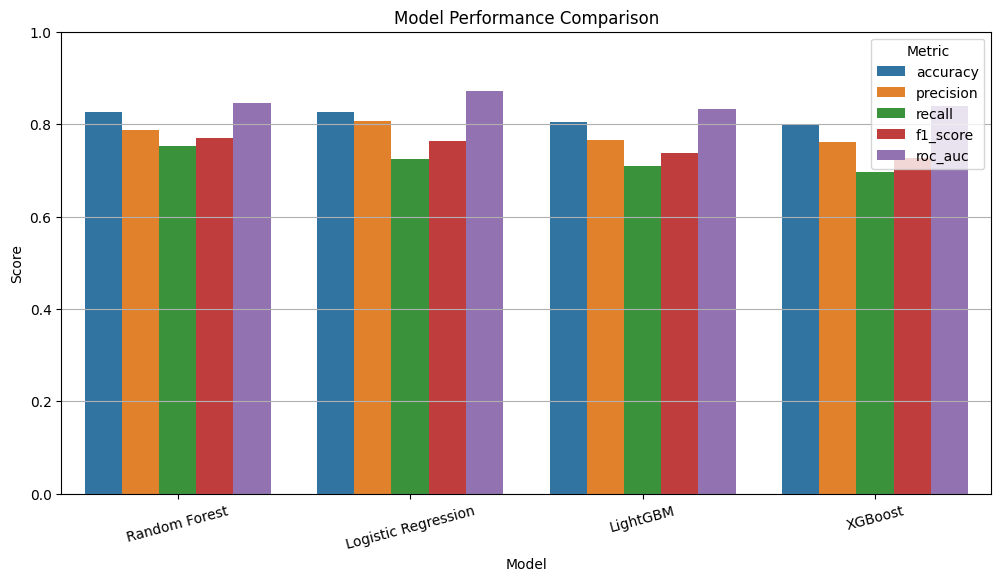

In [51]:
# ------------------------------------------------------------
# 7. 모델별 성능 비교 시각화
# ------------------------------------------------------------

metrics = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

results_melted = results_df.melt(
    id_vars="model",
    value_vars=metrics,
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x="model",
    y="score",
    hue="metric"
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Metric")
plt.show()

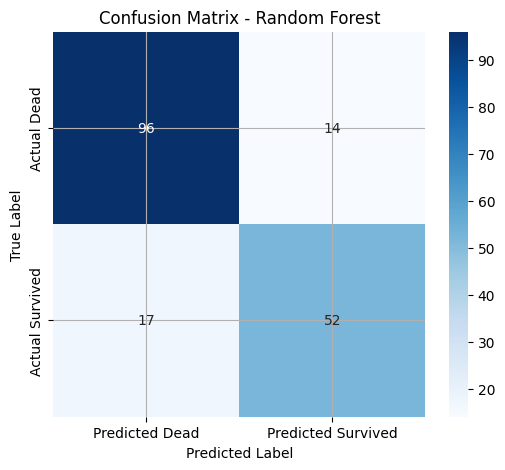

In [52]:
# ------------------------------------------------------------
# 8. 가장 좋은 모델의 Confusion Matrix
# ------------------------------------------------------------

best_y_pred = predictions[best_model_name]

cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Dead", "Predicted Survived"],
    yticklabels=["Actual Dead", "Actual Survived"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [53]:
# ------------------------------------------------------------
# 9. Classification Report
# Precision, Recall, F1-score를 클래스별로 확인
# ------------------------------------------------------------

print(f"[Classification Report - {best_model_name}]")
print(classification_report(y_test, best_y_pred, target_names=["Dead", "Survived"]))

[Classification Report - Random Forest]
              precision    recall  f1-score   support

        Dead       0.85      0.87      0.86       110
    Survived       0.79      0.75      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



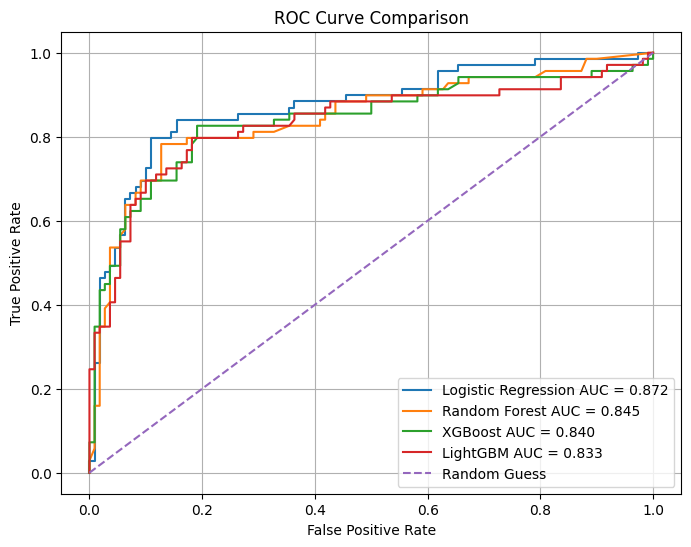

In [54]:
# ------------------------------------------------------------
# 10. ROC Curve 시각화
# ROC-AUC 가점 항목
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for model_name in models.keys():
    y_proba = probabilities[model_name]

    if y_proba is not None:
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)

        plt.plot(fpr, tpr, label=f"{model_name} AUC = {auc_score:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [55]:
# ------------------------------------------------------------
# 11. STEP 05 결과 요약
# ------------------------------------------------------------

print("="*60)
print("STEP 05 모델 학습 및 평가 요약")
print("="*60)

print(f"""
1. 사용한 모델
- Logistic Regression
- Random Forest
{"- XGBoost" if xgboost_available else ""}
{"- LightGBM" if lightgbm_available else ""}

2. 평가 지표
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

3. 가장 좋은 모델
- F1-score 기준 가장 좋은 모델은 {best_model_name}이다.

4. 해석
- Accuracy는 전체 예측 중 맞춘 비율을 의미한다.
- Precision은 생존으로 예측한 승객 중 실제 생존자의 비율이다.
- Recall은 실제 생존자 중 모델이 생존으로 맞춘 비율이다.
- F1-score는 Precision과 Recall의 조화평균으로, 클래스 비율 차이가 있을 때 유용하다.
- ROC-AUC는 모델이 생존자와 사망자를 얼마나 잘 구분하는지를 나타내는 지표이다.

5. 본 실습에서는 Titanic 데이터셋의 클래스 비율이 완전히 균형적이지 않으므로,
   Accuracy뿐만 아니라 F1-score와 ROC-AUC를 함께 고려하여 모델을 평가하였다.
""")

STEP 05 모델 학습 및 평가 요약

1. 사용한 모델
- Logistic Regression
- Random Forest
- XGBoost
- LightGBM

2. 평가 지표
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

3. 가장 좋은 모델
- F1-score 기준 가장 좋은 모델은 Random Forest이다.

4. 해석
- Accuracy는 전체 예측 중 맞춘 비율을 의미한다.
- Precision은 생존으로 예측한 승객 중 실제 생존자의 비율이다.
- Recall은 실제 생존자 중 모델이 생존으로 맞춘 비율이다.
- F1-score는 Precision과 Recall의 조화평균으로, 클래스 비율 차이가 있을 때 유용하다.
- ROC-AUC는 모델이 생존자와 사망자를 얼마나 잘 구분하는지를 나타내는 지표이다.

5. 본 실습에서는 Titanic 데이터셋의 클래스 비율이 완전히 균형적이지 않으므로,
   Accuracy뿐만 아니라 F1-score와 ROC-AUC를 함께 고려하여 모델을 평가하였다.



# 실험 비교 항목

In [56]:
# ============================================================
# 필수 실험 비교 항목
# Base / Exp-1 / Exp-2 / Exp-3 조합별 성능 비교
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [57]:
# ------------------------------------------------------------
# 1. 데이터 로드
# ------------------------------------------------------------

try:
    df
except NameError:
    url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
    df = pd.read_csv(url)

data = df.copy()

print("원본 데이터 shape:", data.shape)
display(data.head())

원본 데이터 shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [58]:
# ------------------------------------------------------------
# 2. 파생 변수 생성
# ------------------------------------------------------------

# 가족 수
data["family_size"] = data["sibsp"] + data["parch"] + 1

# 1인당 요금
data["fare_per_person"] = data["fare"] / data["family_size"]

# 나이 그룹
data["age_group"] = pd.cut(
    data["age"],
    bins=[0, 12, 19, 35, 60, 100],
    labels=["child", "teen", "young_adult", "adult", "senior"]
)

# 어린이 여부
data["is_child"] = np.where(
    data["age"].isnull(),
    np.nan,
    np.where(data["age"] < 12, 1, 0)
)

display(data.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,fare_per_person,age_group,is_child
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2,3.62500,young_adult,0.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2,35.64165,adult,0.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1,7.92500,young_adult,0.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2,26.55000,young_adult,0.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,8.05000,young_adult,0.0


In [59]:
# ------------------------------------------------------------
# 3. 입력 변수 X와 타겟 변수 y 분리
# ------------------------------------------------------------

target = "survived"

# 데이터 누수 및 중복 변수 제거
drop_cols = ["survived", "alive", "deck", "class", "embark_town"]

X = data.drop(columns=drop_cols)
y = data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 14)
y shape: (891,)


In [60]:
# ------------------------------------------------------------
# 4. Base용 변수와 실험용 변수 정의
# ------------------------------------------------------------

# Base는 결측치 처리, 인코딩, 스케일링, Feature Selection 모두 없음
# 따라서 모델이 바로 학습 가능한 원본 수치형 변수만 사용
base_features = [
    "pclass",
    "sibsp",
    "parch",
    "fare"
]

# Exp-1, Exp-2, Exp-3에서 사용할 수치형 변수
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "family_size",
    "fare_per_person",
    "is_child"
]

# Exp-1, Exp-2, Exp-3에서 사용할 범주형 변수
categorical_features = [
    "sex",
    "embarked",
    "who",
    "adult_male",
    "alone",
    "age_group"
]

for col in categorical_features:
    X[col] = X[col].astype("object")

print("Base 변수:", base_features)
print("수치형 변수:", numeric_features)
print("범주형 변수:", categorical_features)

Base 변수: ['pclass', 'sibsp', 'parch', 'fare']
수치형 변수: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'fare_per_person', 'is_child']
범주형 변수: ['sex', 'embarked', 'who', 'adult_male', 'alone', 'age_group']


In [61]:
# ------------------------------------------------------------
# 5. Train/Test Split
# 모든 실험에서 동일한 train/test 데이터 사용
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (712, 14)
X_test shape: (179, 14)


In [62]:
# ------------------------------------------------------------
# 6. 실험 조합에 맞는 전처리기 생성 함수
# ------------------------------------------------------------

def get_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(missing_strategy, encoding_strategy, scaling_strategy):

    # 1. 결측치 처리 방식 설정
    if missing_strategy == "Mean":
        num_imputer = SimpleImputer(strategy="mean")
        cat_imputer = SimpleImputer(strategy="most_frequent")

    elif missing_strategy == "Median":
        num_imputer = SimpleImputer(strategy="median")
        cat_imputer = SimpleImputer(strategy="most_frequent")

    elif missing_strategy == "Most Frequent":
        num_imputer = SimpleImputer(strategy="most_frequent")
        cat_imputer = SimpleImputer(strategy="most_frequent")

    else:
        raise ValueError("지원하지 않는 결측치 처리 방식입니다.")


    # 2. 인코딩 방식 설정
    if encoding_strategy == "One-Hot":
        encoder = get_onehot_encoder()

    elif encoding_strategy == "Label":
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )

    else:
        raise ValueError("지원하지 않는 인코딩 방식입니다.")


    # 3. 스케일링 방식 설정
    if scaling_strategy == "Standard":
        scaler = StandardScaler()

    elif scaling_strategy == "MinMax":
        scaler = MinMaxScaler()

    elif scaling_strategy == "Robust":
        scaler = RobustScaler()

    else:
        raise ValueError("지원하지 않는 스케일링 방식입니다.")


    # 4. 수치형 파이프라인
    numeric_pipeline = Pipeline([
        ("imputer", num_imputer),
        ("scaler", scaler)
    ])


    # 5. 범주형 파이프라인
    categorical_pipeline = Pipeline([
        ("imputer", cat_imputer),
        ("encoder", encoder)
    ])


    # 6. ColumnTransformer
    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

    return preprocessor

In [63]:
# ------------------------------------------------------------
# 7. 전처리 후 변수 이름 가져오는 함수
# ------------------------------------------------------------

def get_feature_names(preprocessor, encoding_strategy):

    if encoding_strategy == "One-Hot":
        cat_encoder = preprocessor.named_transformers_["cat"].named_steps["encoder"]
        cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
        feature_names = numeric_features + list(cat_feature_names)

    elif encoding_strategy == "Label":
        feature_names = numeric_features + categorical_features

    return feature_names

In [64]:
# ------------------------------------------------------------
# 8. 모델 평가 함수
# ------------------------------------------------------------

def calculate_metrics(model, X_train_data, X_test_data, y_train, y_test):

    model.fit(X_train_data, y_train)

    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1]

    result = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

    return result

In [65]:
# ------------------------------------------------------------
# 9. 필수 실험 조합 정의
# ------------------------------------------------------------

experiment_configs = [
    {
        "Experiment": "Base",
        "Missing": "None",
        "Encoding": "None",
        "Scaling": "None",
        "Feature Selection": "X"
    },
    {
        "Experiment": "Exp-1",
        "Missing": "Mean",
        "Encoding": "One-Hot",
        "Scaling": "Standard",
        "Feature Selection": "X"
    },
    {
        "Experiment": "Exp-2",
        "Missing": "Median",
        "Encoding": "Label",
        "Scaling": "MinMax",
        "Feature Selection": "O"
    },
    {
        "Experiment": "Exp-3",
        "Missing": "Most Frequent",
        "Encoding": "One-Hot",
        "Scaling": "Robust",
        "Feature Selection": "O"
    }
]

pd.DataFrame(experiment_configs)

,Experiment,Missing,Encoding,Scaling,Feature Selection
0,Base,None,None,None,X
1,Exp-1,Mean,One-Hot,Standard,X
2,Exp-2,Median,Label,MinMax,O
3,Exp-3,Most Frequent,One-Hot,Robust,O


In [66]:
# ------------------------------------------------------------
# 10. 실험 실행
# ------------------------------------------------------------

comparison_results = []
selected_features_result = {}

top_n = 10

for config in experiment_configs:

    experiment_name = config["Experiment"]
    missing = config["Missing"]
    encoding = config["Encoding"]
    scaling = config["Scaling"]
    feature_selection = config["Feature Selection"]

    print(f"\n실험 진행 중: {experiment_name}")

    # --------------------------------------------------------
    # Base 실험
    # 전처리 없음, 인코딩 없음, 스케일링 없음, Feature Selection 없음
    # 원본 수치형 변수만 사용
    # --------------------------------------------------------
    if experiment_name == "Base":

        X_train_exp = X_train[base_features]
        X_test_exp = X_test[base_features]

        model = LogisticRegression(max_iter=1000)

        metrics = calculate_metrics(
            model=model,
            X_train_data=X_train_exp,
            X_test_data=X_test_exp,
            y_train=y_train,
            y_test=y_test
        )

        n_features = X_train_exp.shape[1]
        selected_features = base_features


    # --------------------------------------------------------
    # Exp-1, Exp-2, Exp-3 실험
    # --------------------------------------------------------
    else:

        # 전처리기 생성
        preprocessor = build_preprocessor(
            missing_strategy=missing,
            encoding_strategy=encoding,
            scaling_strategy=scaling
        )

        # 전처리 적용
        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        # 전처리 후 변수 이름
        feature_names = get_feature_names(preprocessor, encoding)

        # Feature Selection 적용 여부
        if feature_selection == "O":

            # Random Forest로 Feature Importance 계산
            rf_selector = RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )

            rf_selector.fit(X_train_processed, y_train)

            importance_df = pd.DataFrame({
                "feature_index": range(len(feature_names)),
                "feature": feature_names,
                "importance": rf_selector.feature_importances_
            }).sort_values(by="importance", ascending=False)

            # 상위 N개 변수 선택
            selected_indices = importance_df.head(top_n)["feature_index"].values
            selected_features = list(importance_df.head(top_n)["feature"])

            X_train_exp = X_train_processed[:, selected_indices]
            X_test_exp = X_test_processed[:, selected_indices]

        else:
            X_train_exp = X_train_processed
            X_test_exp = X_test_processed
            selected_features = feature_names

        # 모델 학습 및 평가
        model = LogisticRegression(max_iter=1000)

        metrics = calculate_metrics(
            model=model,
            X_train_data=X_train_exp,
            X_test_data=X_test_exp,
            y_train=y_train,
            y_test=y_test
        )

        n_features = X_train_exp.shape[1]


    # 결과 저장
    result_row = {
        "실험": experiment_name,
        "결측치 처리": missing,
        "인코딩": encoding,
        "스케일링": scaling,
        "Feature Selection": feature_selection,
        "사용 변수 수": n_features,
        "Accuracy": metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "F1-score": metrics["F1-score"],
        "ROC-AUC": metrics["ROC-AUC"]
    }

    comparison_results.append(result_row)
    selected_features_result[experiment_name] = selected_features


# 결과표 생성
experiment_comparison_df = pd.DataFrame(comparison_results)

display(experiment_comparison_df)


실험 진행 중: Base

실험 진행 중: Exp-1

실험 진행 중: Exp-2

실험 진행 중: Exp-3


,실험,결측치 처리,인코딩,스케일링,Feature Selection,사용 변수 수,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Base,None,None,None,X,4,0.648045,0.562500,0.391304,0.461538,0.674242
1,Exp-1,Mean,One-Hot,Standard,X,25,0.837989,0.822581,0.739130,0.778626,0.867721
2,Exp-2,Median,Label,MinMax,O,10,0.815642,0.800000,0.695652,0.744186,0.870883
3,Exp-3,Most Frequent,One-Hot,Robust,O,10,0.826816,0.806452,0.724638,0.763359,0.863505


In [67]:
# ------------------------------------------------------------
# 11. F1-score 기준 정렬
# ------------------------------------------------------------

experiment_comparison_sorted = experiment_comparison_df.sort_values(
    by="F1-score",
    ascending=False
)

display(experiment_comparison_sorted)

,실험,결측치 처리,인코딩,스케일링,Feature Selection,사용 변수 수,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Exp-1,Mean,One-Hot,Standard,X,25,0.837989,0.822581,0.739130,0.778626,0.867721
3,Exp-3,Most Frequent,One-Hot,Robust,O,10,0.826816,0.806452,0.724638,0.763359,0.863505
2,Exp-2,Median,Label,MinMax,O,10,0.815642,0.800000,0.695652,0.744186,0.870883
0,Base,None,None,None,X,4,0.648045,0.562500,0.391304,0.461538,0.674242


In [68]:
# ------------------------------------------------------------
# 12. Feature Selection 적용 실험의 선택 변수 확인
# ------------------------------------------------------------

for exp_name, features in selected_features_result.items():
    print(f"\n[{exp_name}] 사용 변수")
    print(features)


[Base] 사용 변수
['pclass', 'sibsp', 'parch', 'fare']

[Exp-1] 사용 변수
['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'fare_per_person', 'is_child', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'who_child', 'who_man', 'who_woman', 'adult_male_False', 'adult_male_True', 'alone_False', 'alone_True', 'age_group_adult', 'age_group_child', 'age_group_senior', 'age_group_teen', 'age_group_young_adult']

[Exp-2] 사용 변수
['age', 'fare_per_person', 'fare', 'adult_male', 'sex', 'who', 'pclass', 'family_size', 'sibsp', 'age_group']

[Exp-3] 사용 변수
['fare_per_person', 'age', 'fare', 'who_man', 'adult_male_False', 'adult_male_True', 'pclass', 'sex_female', 'sex_male', 'family_size']


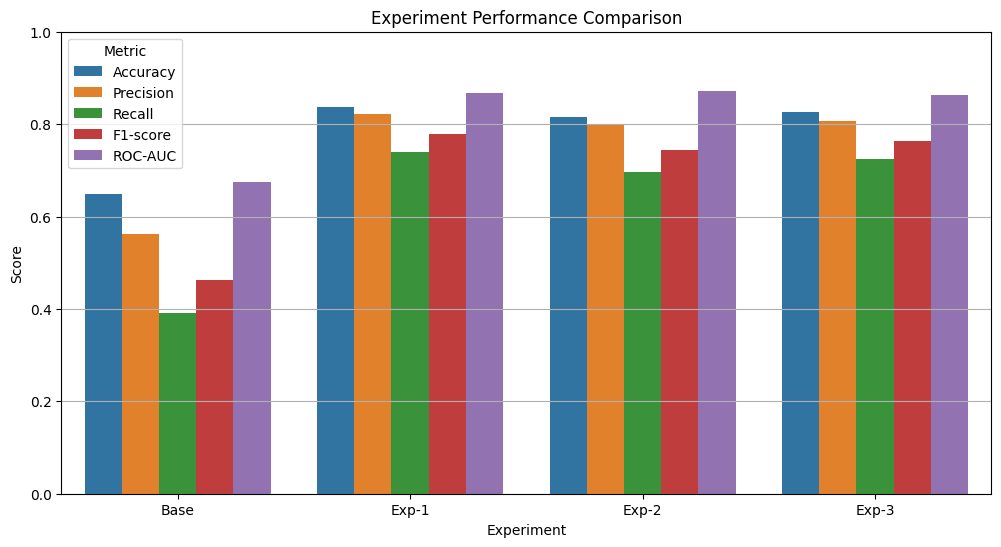

In [69]:
# ------------------------------------------------------------
# 13. 실험별 성능 비교 시각화
# ------------------------------------------------------------

metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

comparison_melted = experiment_comparison_df.melt(
    id_vars=["실험"],
    value_vars=metrics,
    var_name="평가지표",
    value_name="점수"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_melted,
    x="실험",
    y="점수",
    hue="평가지표"
)

plt.title("Experiment Performance Comparison")
plt.xlabel("Experiment")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.show()

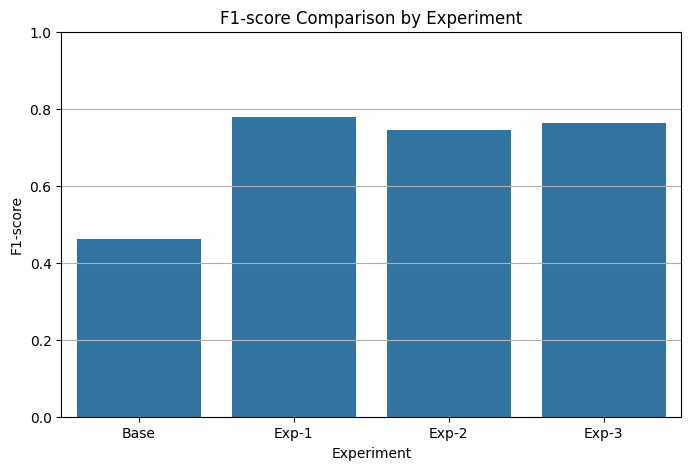

In [70]:
# ------------------------------------------------------------
# 14. F1-score 기준 실험 비교
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=experiment_comparison_df,
    x="실험",
    y="F1-score"
)

plt.title("F1-score Comparison by Experiment")
plt.xlabel("Experiment")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.show()

In [71]:
# ------------------------------------------------------------
# 15. 보고서용 비교표
# ------------------------------------------------------------

report_table = experiment_comparison_df.copy()

report_table[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]] = report_table[
    ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
].round(4)

display(report_table)

,실험,결측치 처리,인코딩,스케일링,Feature Selection,사용 변수 수,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Base,None,None,None,X,4,0.6480,0.5625,0.3913,0.4615,0.6742
1,Exp-1,Mean,One-Hot,Standard,X,25,0.8380,0.8226,0.7391,0.7786,0.8677
2,Exp-2,Median,Label,MinMax,O,10,0.8156,0.8000,0.6957,0.7442,0.8709
3,Exp-3,Most Frequent,One-Hot,Robust,O,10,0.8268,0.8065,0.7246,0.7634,0.8635


In [72]:
# ============================================================
# 가산점 1, 2. Pipeline 객체 + GridSearchCV 하이퍼파라미터 튜닝
# ============================================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 기존 함수 build_preprocessor() 재사용
grid_preprocessor = build_preprocessor(
    missing_strategy="Median",
    encoding_strategy="One-Hot",
    scaling_strategy="Robust"
)

grid_pipeline = Pipeline([
    ("preprocessor", grid_preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = [
    {
        "model": [LogisticRegression(max_iter=1000, random_state=42)],
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model": [RandomForestClassifier(random_state=42, class_weight="balanced")],
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 3, 5, 8],
        "model__min_samples_split": [2, 5, 10]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

grid_search = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1-score:")
print(grid_search.best_score_)

best_grid_model = grid_search.best_estimator_

y_pred_grid = best_grid_model.predict(X_test)
y_proba_grid = best_grid_model.predict_proba(X_test)[:, 1]

grid_result = {
    "실험": "GridSearchCV Best Pipeline",
    "Accuracy": accuracy_score(y_test, y_pred_grid),
    "Precision": precision_score(y_test, y_pred_grid),
    "Recall": recall_score(y_test, y_pred_grid),
    "F1-score": f1_score(y_test, y_pred_grid),
    "ROC-AUC": roc_auc_score(y_test, y_proba_grid)
}

grid_result_df = pd.DataFrame([grid_result])
display(grid_result_df)

# GridSearchCV 전체 결과표
grid_cv_results_df = pd.DataFrame(grid_search.cv_results_)
display(
    grid_cv_results_df[
        [
            "rank_test_f1",
            "mean_test_f1",
            "mean_test_accuracy",
            "mean_test_precision",
            "mean_test_recall",
            "mean_test_roc_auc",
            "params"
        ]
    ].sort_values("rank_test_f1").head(10)
)

Fitting 5 folds for each of 44 candidates, totalling 220 fits
Best Parameters:
{'model': RandomForestClassifier(class_weight='balanced', random_state=42), 'model__max_depth': 8, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best CV F1-score:
0.7830255424722303


,실험,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,GridSearchCV Best Pipeline,0.787709,0.71831,0.73913,0.728571,0.846311


,rank_test_f1,mean_test_f1,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,params
38,1,0.783026,0.835723,0.802013,0.769293,0.879104,{'model': RandomForestClassifier(class_weight=...
39,2,0.782293,0.834335,0.796270,0.772997,0.881678,{'model': RandomForestClassifier(class_weight=...
40,3,0.780057,0.832936,0.795276,0.769360,0.882262,{'model': RandomForestClassifier(class_weight=...
43,4,0.776312,0.828711,0.784677,0.772929,0.882065,{'model': RandomForestClassifier(class_weight=...
26,5,0.775500,0.830109,0.788023,0.765320,0.879489,{'model': RandomForestClassifier(class_weight=...
27,6,0.774614,0.827302,0.779335,0.772660,0.879450,{'model': RandomForestClassifier(class_weight=...
13,7,0.774404,0.828691,0.785571,0.765657,0.880772,{'model': RandomForestClassifier(class_weight=...
12,8,0.774378,0.828681,0.786294,0.765657,0.880767,{'model': RandomForestClassifier(class_weight=...
15,9,0.773077,0.827292,0.783713,0.765724,0.883281,{'model': RandomForestClassifier(class_weight=...
16,10,0.772976,0.827292,0.783883,0.765657,0.883786,{'model': RandomForestClassifier(class_weight=...


,feature,importance_mean,importance_std
8,adult_male,0.047098,0.025589
7,who,0.015378,0.018693
10,family_size,0.013566,0.005878
6,embarked,0.004311,0.010394
1,sex,0.002866,0.012427
13,is_child,0.000000,0.000000
4,parch,-0.002157,0.007183
12,age_group,-0.005219,0.012098
2,age,-0.006279,0.011676
5,fare,-0.006652,0.014521


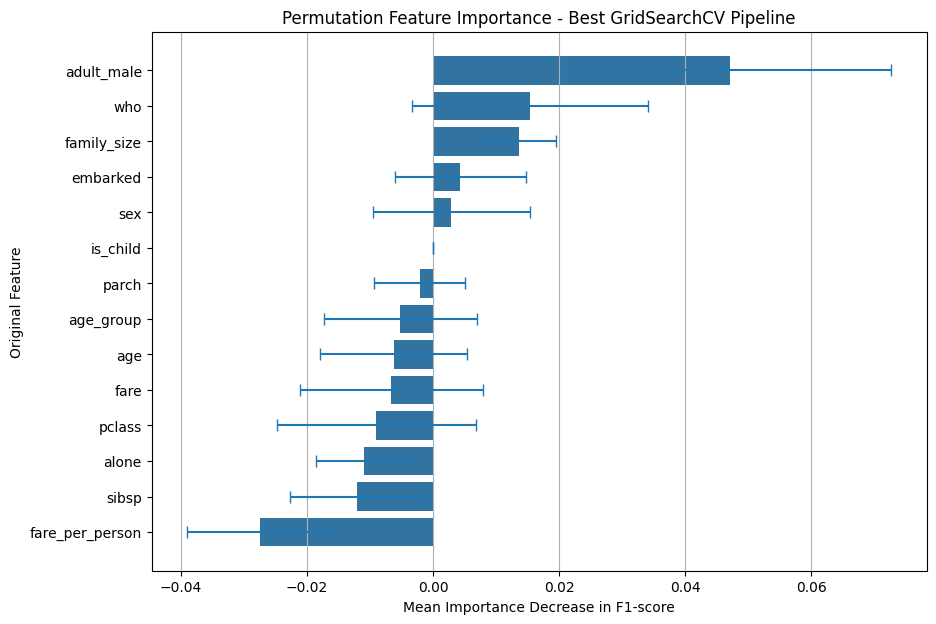

In [73]:
# ============================================================
# 가산점 5. Feature Importance 시각화 고도화
# Permutation Importance
# ============================================================

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_grid_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_importance_df)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=perm_importance_df.head(15),
    x="importance_mean",
    y="feature"
)

plt.errorbar(
    x=perm_importance_df.head(15)["importance_mean"],
    y=np.arange(min(15, len(perm_importance_df))),
    xerr=perm_importance_df.head(15)["importance_std"],
    fmt="none",
    capsize=4
)

plt.title("Permutation Feature Importance - Best GridSearchCV Pipeline")
plt.xlabel("Mean Importance Decrease in F1-score")
plt.ylabel("Original Feature")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: U

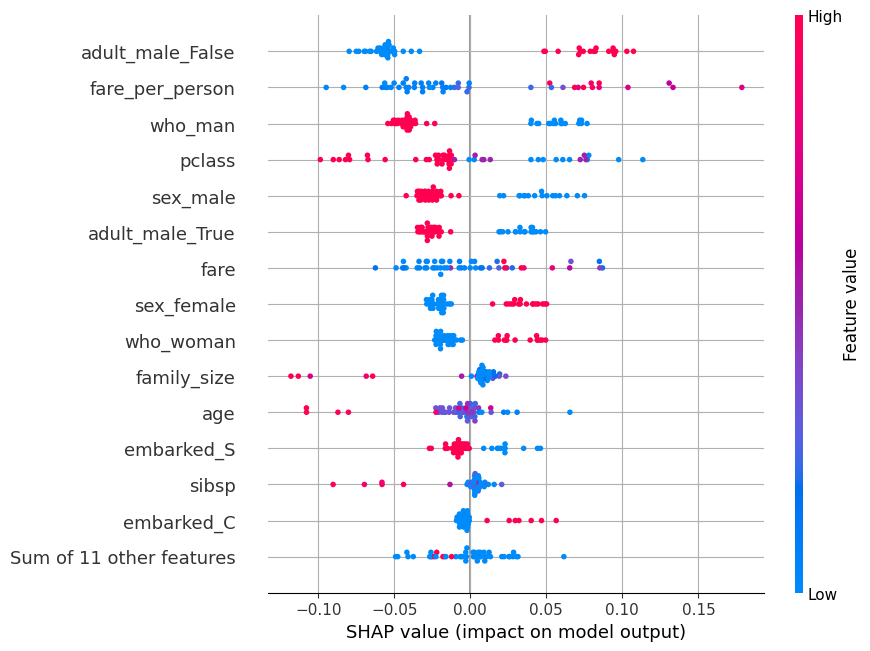

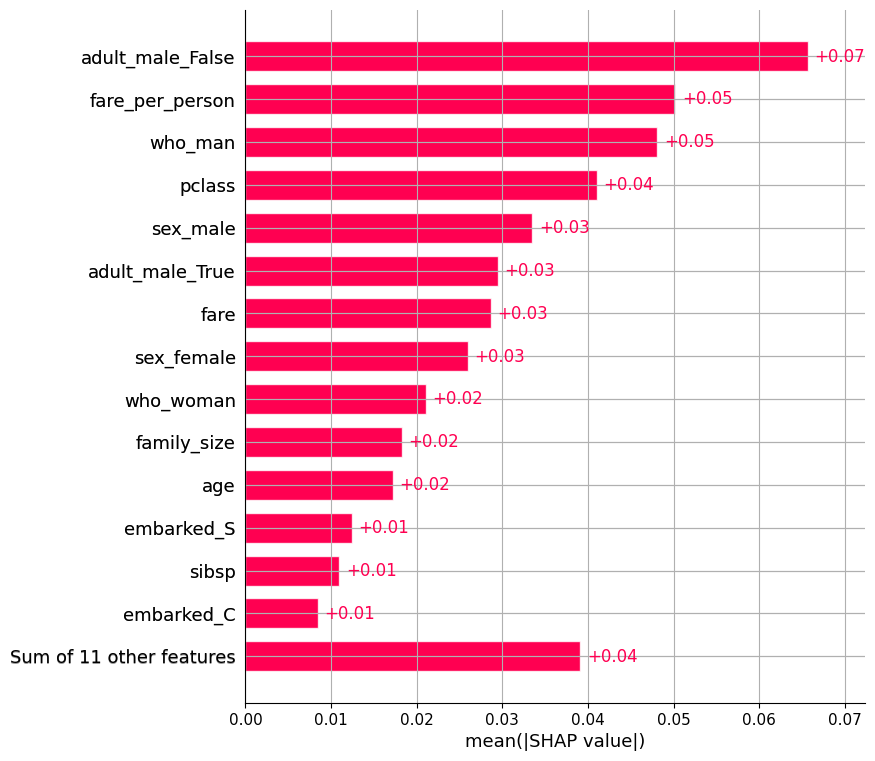

In [74]:
# ============================================================
# 가산점 3. SHAP 기반 설명 가능성 분석
# ============================================================

import shap

# GridSearchCV의 best pipeline에서 전처리기와 모델 분리
best_preprocessor = best_grid_model.named_steps["preprocessor"]
best_model_only = best_grid_model.named_steps["model"]

# 전처리된 데이터 생성
X_train_processed = best_preprocessor.transform(X_train)
X_test_processed = best_preprocessor.transform(X_test)

# 전처리 후 feature name 가져오기
try:
    shap_feature_names = get_feature_names(best_preprocessor, "One-Hot")
except:
    shap_feature_names = [f"feature_{i}" for i in range(X_train_processed.shape[1])]

X_train_shap = pd.DataFrame(X_train_processed, columns=shap_feature_names)
X_test_shap = pd.DataFrame(X_test_processed, columns=shap_feature_names)

# 계산 속도를 위해 일부 샘플만 사용
X_train_sample = X_train_shap.sample(min(100, len(X_train_shap)), random_state=42)
X_test_sample = X_test_shap.sample(min(50, len(X_test_shap)), random_state=42)

# SHAP Explainer
explainer = shap.Explainer(best_model_only.predict_proba, X_train_sample)
shap_values = explainer(X_test_sample)

# 이진 분류에서 생존 클래스(1)에 대한 SHAP 값 사용
if len(shap_values.values.shape) == 3:
    shap_values_survived = shap_values[:, :, 1]
else:
    shap_values_survived = shap_values

# SHAP Summary Plot
shap.plots.beeswarm(shap_values_survived, max_display=15)

# SHAP Bar Plot
shap.plots.bar(shap_values_survived, max_display=15)

LIME 설명 결과:


,Feature Condition,Contribution
0,adult_male_False <= 0.00,-0.133933
1,0.00 < who_man <= 1.00,-0.097632
2,0.00 < sex_male <= 1.00,-0.071178
3,0.00 < adult_male_True <= 1.00,-0.066463
4,-1.00 < pclass <= 0.00,-0.064621
5,sex_female <= 0.00,-0.059610
6,who_woman <= 0.00,-0.049806
7,-0.09 < fare_per_person <= 0.00,-0.043594
8,sibsp > 1.00,-0.039880
9,age_group_child <= 0.00,-0.036924


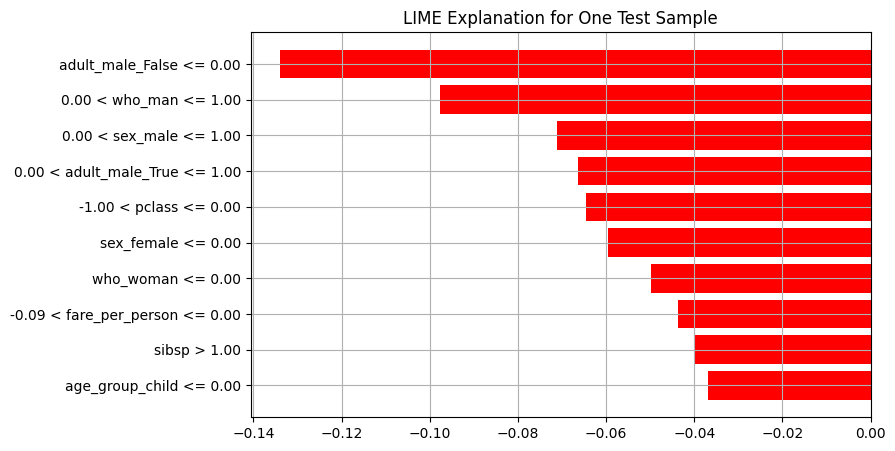

In [75]:
# ============================================================
# 가산점 3. LIME 기반 설명 가능성 분석
# ============================================================

try:
    from lime.lime_tabular import LimeTabularExplainer
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lime"])
    from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_shap),
    feature_names=shap_feature_names,
    class_names=["Dead", "Survived"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# 테스트 데이터 중 첫 번째 샘플 설명
sample_idx = 0

lime_exp = lime_explainer.explain_instance(
    data_row=np.array(X_test_shap.iloc[sample_idx]),
    predict_fn=best_model_only.predict_proba,
    num_features=10
)

print("LIME 설명 결과:")
display(pd.DataFrame(lime_exp.as_list(), columns=["Feature Condition", "Contribution"]))

fig = lime_exp.as_pyplot_figure()
plt.title("LIME Explanation for One Test Sample")
plt.show()

In [76]:
# ============================================================
# 가산점 4. AutoML 비교 실험
# FLAML AutoML 사용
# ============================================================

try:
    from flaml import AutoML
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "flaml"])
    from flaml import AutoML

automl = AutoML()

automl_settings = {
    "time_budget": 60,
    "metric": "f1",
    "task": "classification",
    "seed": 42,
    "verbose": 0
}

# AutoML에는 전처리 완료된 데이터 사용
X_train_automl = X_train_shap
X_test_automl = X_test_shap

automl.fit(
    X_train=X_train_automl,
    y_train=y_train,
    **automl_settings
)

print("AutoML Best Estimator:")
print(automl.best_estimator)

print("\nAutoML Best Config:")
print(automl.best_config)

y_pred_automl = automl.predict(X_test_automl)
y_proba_automl = automl.predict_proba(X_test_automl)[:, 1]

automl_result = {
    "실험": "FLAML AutoML",
    "Accuracy": accuracy_score(y_test, y_pred_automl),
    "Precision": precision_score(y_test, y_pred_automl),
    "Recall": recall_score(y_test, y_pred_automl),
    "F1-score": f1_score(y_test, y_pred_automl),
    "ROC-AUC": roc_auc_score(y_test, y_proba_automl)
}

automl_result_df = pd.DataFrame([automl_result])
display(automl_result_df)

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


AutoML Best Estimator:
lgbm

AutoML Best Config:
{'n_estimators': 26, 'num_leaves': 11, 'min_child_samples': 37, 'learning_rate': np.float64(0.2965439939666562), 'log_max_bin': 6, 'colsample_bytree': np.float64(0.871563772981322), 'reg_alpha': np.float64(0.01305449887292375), 'reg_lambda': np.float64(0.042638296688962525)}


,실험,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,FLAML AutoML,0.787709,0.754098,0.666667,0.707692,0.830962


,실험,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Exp-1,0.837989,0.822581,0.739130,0.778626,0.867721
3,Exp-3,0.826816,0.806452,0.724638,0.763359,0.863505
2,Exp-2,0.815642,0.800000,0.695652,0.744186,0.870883
4,GridSearchCV Best Pipeline,0.787709,0.718310,0.739130,0.728571,0.846311
5,FLAML AutoML,0.787709,0.754098,0.666667,0.707692,0.830962
0,Base,0.648045,0.562500,0.391304,0.461538,0.674242


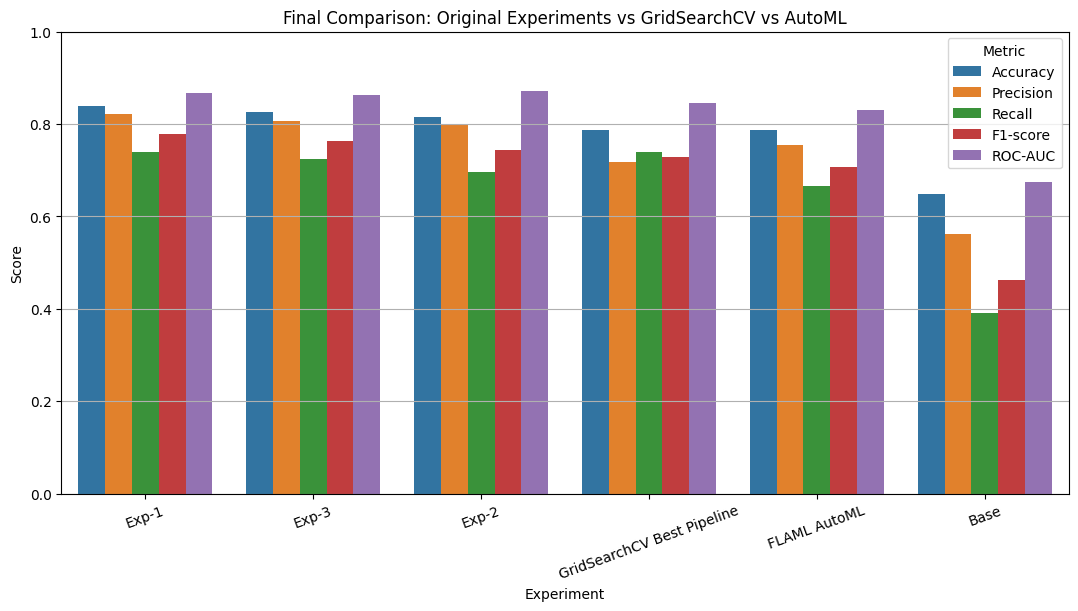

In [77]:
# ============================================================
# 전체 실험 결과 통합 비교
# ============================================================

bonus_comparison_df = pd.concat(
    [
        experiment_comparison_df[["실험", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]],
        grid_result_df,
        automl_result_df
    ],
    ignore_index=True
)

bonus_comparison_df = bonus_comparison_df.sort_values("F1-score", ascending=False)

display(bonus_comparison_df)

bonus_melted = bonus_comparison_df.melt(
    id_vars="실험",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="평가지표",
    value_name="점수"
)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=bonus_melted,
    x="실험",
    y="점수",
    hue="평가지표"
)

plt.title("Final Comparison: Original Experiments vs GridSearchCV vs AutoML")
plt.xlabel("Experiment")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.show()